<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Ehrenfest_Derivation_Engine_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Automated Mathematical Derivation Engine

A mathematical expression often admits several equivalent forms, yet only a few expose the structure needed for a particular calculation. Automated derivation requires a way to select transformations, preserve their assumptions, and distinguish exact results from numerical agreement. This Google Colab notebook implements an open source engine that connects symbolic transformations to a searchable derivation graph, preserving the relationship between each mathematical step and its verification status.

## Symbols and Terminology

Within a derivation, an expression carries mathematical conditions that determine which transformations are admissible. Recording those conditions alongside search costs and verification results makes the resulting path interpretable.

| Symbol or term | Definition |
|---|---|
| $E$ | **Current expression** represented at a search node. |
| $E_0$ | **Starting expression** supplied to the engine. |
| $T$ | **Target expression**, if the objective specifies an exact target. |
| $E'$ | **Candidate expression** produced by applying a transformation to $E$. |
| $\mathcal{A}$ | **Assumptions** governing the expressions and admissible transformations. |
| $r$ | **Transformation rule** selected from the configurable registry. |
| $R$ | **Equivalence residual**, defined as the difference between a candidate expression and its predecessor for supported expressions. |
| $C(E)$ | **Search score** assigned to a node containing $E$, including its path and rule metadata. |
| $w_d, w_o, w_t, w_c, w_r, w_v$ | **Weights** controlling the contributions of the six score components. |
| $C_{\mathrm{depth}}$ | **Depth cost** associated with the recorded derivation path. |
| $C_{\mathrm{operations}}$ | **Operation cost** obtained from `SymPy.count_ops(E)`. |
| $C_{\mathrm{target}}$ | **Target cost** based on structural matching and the simplified target residual. |
| $C_{\mathrm{canonical}}$ | **Canonical-form cost** associated with the selected mathematical objective. |
| $C_{\mathrm{rule}}$ | **Rule cost** obtained from the transformation registry. |
| $C_{\mathrm{verification}}$ | **Verification cost** determined by the status of the candidate transformation. |
| $x$ | **Position coordinate** in the one-dimensional physical example. |
| $t$ | **Time** in the packet dynamics. |
| $m$ | **Particle mass**, assumed positive and constant. |
| $V(x)$ | **Potential energy** as a function of position. |
| $\langle \cdot \rangle$ | **Quantum expectation value** evaluated in the evolving state. |
| DAG | **Directed acyclic graph**, a directed graph containing zero directed cycles. |
| SMT | **Satisfiability modulo theories**, the evaluation of logical constraints within specified mathematical theories. |
| CPU | **Central processing unit**, used for symbolic work and the NumPy numerical backend. |
| GPU | **Graphics processing unit**, used for supported CuPy calculations. |
| CUDA | **NVIDIA’s computing platform** required by the optional CuPy GPU execution path. |

## Fundamental Theory

A derivation preserves a mathematical relationship across a sequence of justified transformations. For an equivalence-preserving rule, correctness concerns every admissible input under the represented assumptions, extending beyond agreement at selected numerical points.

The **candidate expression** produced by a registered rule is defined by

$$
E' := r(E).
$$

For supported scalar expressions, subtracting the original expression provides an **equivalence residual**,

$$
R := E' - E.
$$

Exact symbolic verification succeeds if supported symbolic operations reduce this residual to exactly zero under $\mathcal{A}$, with the expressions interpreted on their admissible domain. Structural equality provides a separate test of expression representation; mathematically equivalent expressions may have different structures. [1](https://docs.sympy.org/latest/tutorials/intro-tutorial/gotchas.html)

For supported algebraic statements, SMT verification asks whether the encoded assumptions admit a counterexample to the proposed equality. An `unsat` result excludes such a counterexample within the encoded theory; an `unknown` result leaves the query unresolved. [2](https://microsoft.github.io/z3guide/docs/logic/intro/)

*   **Formal proof**
    *   *Acceptance criterion:* A proof assistant checks a proof object.
    *   *Interpretation and scope:* This engine produces derivation records without generating proof-assistant certificates.
*   **Exact symbolic verification**
    *   *Acceptance criterion:* Supported symbolic operations reduce the residual to exactly zero under represented assumptions.
    *   *Interpretation and scope:* The equality holds within the represented mathematical domain and the correctness of the symbolic operations.
*   **SMT verification**
    *   *Acceptance criterion:* Z3 returns `unsat` for the encoded counterexample query.
    *   *Interpretation and scope:* The equality follows from the encoded assumptions within the supported theory.
*   **Numerical consistency checking**
    *   *Acceptance criterion:* Evaluations at sampled admissible points agree within the configured tolerances.
    *   *Interpretation and scope:* Agreement supports a numerical consistency result; unsampled inputs and unresolved analytical conditions lie outside its scope.

Numerical agreement retains its numerical label throughout the derivation. Increasing arithmetic precision or sample count strengthens the check without converting it into a universal proof.

## Implementation and Control Knobs

Searching for a derivation introduces a computational problem alongside the algebraic problem. Each transformation expands the candidate space, making search order and expression complexity central to runtime and memory use.

The engine accepts a starting expression with its assumptions, together with an exact target or a mathematical objective. A configurable registry supplies candidate transformations, and search controls determine which candidates receive further exploration.

*   **SymPy**
    *   *Computational role:* Performs symbolic transformations and exact equivalence checks.
    *   *Contribution to the derivation:* Generates candidate expressions and evaluates supported symbolic residuals.
*   **NetworkX**
    *   *Computational role:* Represents the directed graph and supports traversal, path selection, and structural analysis.
    *   *Contribution to the derivation:* Connects expressions to their transformation histories and associated metadata.
*   **Graphviz**
    *   *Computational role:* Renders the graph with hierarchical node and edge placement.
    *   *Contribution to the derivation:* Makes alternative paths and rule applications visually inspectable.
*   **Z3**
    *   *Computational role:* Evaluates supported algebraic counterexample queries.
    *   *Contribution to the derivation:* Adds SMT verification under encoded assumptions.
*   **mpmath**
    *   *Computational role:* Performs independent high-precision scalar evaluations.
    *   *Contribution to the derivation:* Checks numerical consistency at sampled admissible inputs.
*   **CuPy**
    *   *Computational role:* Performs batched numerical calculations on a compatible CUDA GPU.
    *   *Contribution to the derivation:* Accelerates supported numerical checks at sufficient batch sizes.
*   **NumPy**
    *   *Computational role:* Provides CPU numerical execution for the Ehrenfest example.
    *   *Contribution to the derivation:* Supports packet calculations without a CUDA runtime.
*   **SageMath**
    *   *Computational role:* Serves as an optional future backend.
    *   *Contribution to the derivation:* Offers a potential extension toward advanced algebra and algebraic topology.

NetworkX supplies graph algorithms independently of the mathematical meaning assigned to an edge. Correct interpretation of a selected path consequently requires the engine’s rule metadata and verification records. [3](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html)

To expose the tradeoffs controlling exploration, the **search score** is defined as

$$
\begin{aligned}
C(E) := {}&
w_d C_{\mathrm{depth}}
+ w_o C_{\mathrm{operations}}
+ w_t C_{\mathrm{target}} \\
&+ w_c C_{\mathrm{canonical}}
+ w_r C_{\mathrm{rule}}
+ w_v C_{\mathrm{verification}}.
\end{aligned}
$$

Although written as a function of the expression, this score also includes metadata associated with the node and its recorded path. Every contribution is inspectable.

*   **$C_{\mathrm{depth}}$**
    *   *Calculation or interpretation:* Depth along the recorded derivation path.
    *   *Effect of increasing its weight:* Favors shorter paths.
*   **$C_{\mathrm{operations}}$**
    *   *Calculation or interpretation:* `SymPy.count_ops(E)`.
    *   *Effect of increasing its weight:* Favors expressions with fewer symbolic operations.
*   **$C_{\mathrm{target}}$**
    *   *Calculation or interpretation:* Zero for a structural target match; otherwise, the operation count of the simplified target residual plus one.
    *   *Effect of increasing its weight:* Favors candidates with smaller residual expressions under this heuristic.
*   **$C_{\mathrm{canonical}}$**
    *   *Calculation or interpretation:* Objective-specific canonical-form penalty or metric.
    *   *Effect of increasing its weight:* Favors the representation specified by the objective.
*   **$C_{\mathrm{rule}}$**
    *   *Calculation or interpretation:* Cost stored in the rule registry.
    *   *Effect of increasing its weight:* Discourages transformations assigned higher costs.
*   **$C_{\mathrm{verification}}$**
    *   *Calculation or interpretation:* Zero for exact symbolic verification, a small penalty for SMT verification, a larger penalty for numerical-only consistency, and a large penalty for a failed transformation.
    *   *Effect of increasing its weight:* Changes the search preference among verification outcomes.

All score terms appear in the displayed definition. A penalty affects ranking; acceptance of a transformation requires a separate decision about mathematical validity.

Breadth-first search explores candidates by depth, making it appropriate for seeking a path with the fewest transformations under uniform step costs. Best-first search prioritizes the configured score, and A*-style search combines accumulated cost with a heuristic estimate of the remaining cost. An optimality guarantee requires the corresponding assumptions about costs, heuristic admissibility, and graph-search handling.

## Mathematical and Computational Nuances

Equivalent-looking expressions may differ at singularities or across complex branches. In operator algebra, changing the order of factors may also change the expression itself, requiring transformation rules that respect the relevant algebra.

Cancellation requires attention to excluded denominator zeros, and logarithmic or radical identities require appropriate domain assumptions. A symbolic result inherits the conditions represented by the engine; unsupported conditions require separate mathematical treatment.

For the Ehrenfest example, operator transformations are conditional on the supplied commutation relations and analytical assumptions. Successful rewriting records consequences of those inputs without independently proving operator-domain properties or boundary conditions.

Reversible rules may create cycles in the full transformation graph. A hierarchical Graphviz layout alone provides zero assurance of acyclicity; describing a rendered derivation as a DAG requires an acyclic retained graph or an acyclic extraction of derivation paths.

Numerical checks introduce additional sensitivity to sampling and arithmetic precision. Singular regions require admissible sample selection, and cancellation may require higher precision to distinguish a small residual from roundoff error. GPU execution primarily benefits sufficiently large numerical batches, with transfer costs and available device memory influencing performance.

## Practical Application and Observation

The Ehrenfest example connects conditional operator algebra to the motion of a quantum packet’s mean position. Comparing harmonic and quartic potentials exposes how the spatial distribution of a state enters its mean acceleration.

For a one-dimensional particle with the usual kinetic energy and a differentiable potential, the Ehrenfest relation gives

$$
m\frac{\mathrm{d}^2\langle x\rangle}{\mathrm{d}t^2}
=
-\left\langle
\frac{\mathrm{d}V(x)}{\mathrm{d}x}
\right\rangle.
$$

This relation assumes sufficient regularity of the state and operators, finite required expectations, and boundary behavior that permits the derivation. Within the engine, its symbolic derivation is conditional on the encoded operator identities and associated assumptions.

For a harmonic potential, the force is linear in position, allowing the mean position to satisfy the classical harmonic equation exactly under these conditions. A quartic contribution introduces a cubic force term, making the mean acceleration sensitive to higher position moments.

The numerical comparison examines agreement with these conditional symbolic predictions. Execution proceeds in cell order, with NumPy supporting CPU calculations and optional CuPy supporting a compatible CUDA runtime.

*   **Derivation path**
    *   *What it reveals:* Rules connecting the starting expression to the selected result.
    *   *Interpretation:* A traceable sequence of mathematical transformations.
*   **Verification status**
    *   *What it reveals:* The check attached to each transformation.
    *   *Interpretation:* The scope of support for each step.
*   **Search score**
    *   *What it reveals:* Contributions that affected candidate priority.
    *   *Interpretation:* The computational preferences shaping exploration.
*   **Mean position**
    *   *What it reveals:* Motion of the packet’s center.
    *   *Interpretation:* A direct comparison with the predicted mean dynamics.
*   **Mean force**
    *   *What it reveals:* The expectation of the force across the packet.
    *   *Interpretation:* The quantity governing Ehrenfest acceleration.
*   **Numerical residual**
    *   *What it reveals:* Disagreement between evaluated quantities.
    *   *Interpretation:* Sensitivity to numerical accuracy, discretization, and model assumptions.

## Comparison of Approaches

Automated derivation combines mathematical checking with computational exploration. Keeping these responsibilities separate permits changes to search priorities without changing the interpretation of a verification result.

*   **Symbolic transformation**
    *   *Primary strength:* Produces exact expressions and supports exact residual checks.
    *   *Scope boundary:* Coverage follows the implemented rules and represented assumptions.
*   **SMT reasoning**
    *   *Primary strength:* Excludes encoded counterexamples within supported theories.
    *   *Scope boundary:* Conclusions apply to the translated statement and assumptions.
*   **Numerical evaluation**
    *   *Primary strength:* Examines behavior across sampled inputs and evolving states.
    *   *Scope boundary:* Agreement applies to evaluated cases within numerical accuracy.
*   **Graph search**
    *   *Primary strength:* Organizes alternatives and selects derivation paths.
    *   *Scope boundary:* Path selection alone supplies zero mathematical assurance.
*   **Graph rendering**
    *   *Primary strength:* Exposes branching and transformation history.
    *   *Scope boundary:* Visual structure requires interpretation alongside verification metadata.
*   **GPU acceleration**
    *   *Primary strength:* Increases throughput for supported batched calculations.
    *   *Scope boundary:* Benefits vary with workload size, memory, and transfer overhead.

The engine produces searchable derivations with inspectable assumptions and verification records, connecting exact algebra to numerical exploration.

## References

Symbolic equality, logical satisfiability, and graph traversal address different technical questions. Their software documentation defines the behavior underlying the corresponding computational components.

1. SymPy Development Team. (n.d.). “Gotchas.” *SymPy Documentation*, introductory tutorial. Living documentation; accessed September 16, 2026. [SymPy equality and symbolic-expression guidance](https://docs.sympy.org/latest/tutorials/intro-tutorial/gotchas.html).

2. Z3 Project. (n.d.). “Introduction.” *Online Z3 Guide*, logic documentation. Living documentation; accessed September 16, 2026. [Z3 assertions and satisfiability results](https://microsoft.github.io/z3guide/docs/logic/intro/).

3. NetworkX Developers. (n.d.). “Shortest Paths.” *NetworkX Documentation*, algorithms reference. Living documentation; accessed September 16, 2026. [NetworkX path-finding algorithms](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html).

In [1]:
"""Install the derivation and Graphviz rendering stack for Google Colab."""

!apt-get -qq update
!apt-get -qq install -y graphviz
!uv pip install -q graphviz sympy networkx z3-solver mpmath cupy-cuda12x numpy scipy matplotlib pandas

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
"""Import dependencies and define user-adjustable controls."""

from collections import Counter, deque
import heapq
import itertools
import math
import random

import mpmath
import graphviz
import networkx as nx
import pandas as pd
import sympy as sp
from IPython.display import Math, SVG, display
import z3

try:
    import cupy as cp
except ImportError:
    cp = None


# - Core search controls ------------------------------------------------------
SEARCH_MODE = "astar"  # "breadth_first", "best_first", or "astar"
MAX_DEPTH = 5
MAX_NODES = 220
STOP_AFTER_GOALS = 5
TOP_CANDIDATES = 8

# - Verification controls ----------------------------------------------------
MPMATH_SAMPLES = 12
GPU_SAMPLES = 32768
MPMATH_DPS = 70
NUMERIC_TOLERANCE = 1e-10
RANDOM_SEED = 7

# - Search score weights -----------------------------------------------------
SCORE_WEIGHTS = {
    "depth": 1.00,
    "operations": 0.08,
    "target": 1.25,
    "canonical": 1.00,
    "rule": 0.30,
    "verification": 1.00,
}

# - Mathematical assumptions ------------------------------------------------
ASSUMPTIONS = {
    "x": {"real": True, "positive": True},
    "y": {"real": True},
    "n": {"integer": True, "nonnegative": True},
}

# - Transformation controls -------------------------------------------------
PERMITTED_RULES = (
    "expand",
    "factor",
    "cancel",
    "together",
    "apart",
    "trigsimp",
    "powsimp",
    "ratsimp",
    "collect",
    "simplify",
)
COLLECT_SYMBOL_NAME = "x"

# - Graphviz rendering --------------------------------------------------------
GRAPHVIZ_DPI = 250
GRAPHVIZ_RANKDIR = "LR"
GRAPHVIZ_MAX_LABEL_CHARS = 72

random.seed(RANDOM_SEED)
mpmath.mp.dps = MPMATH_DPS
sp.init_printing()

GPU_AVAILABLE = False
if cp is not None:
    try:
        GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    except cp.cuda.runtime.CUDARuntimeError:
        GPU_AVAILABLE = False

print(f"CUDA-backed CuPy available: {GPU_AVAILABLE}")

CUDA-backed CuPy available: True


## Mathematical state, assumptions, and rule registry

Symbols are constructed from an assumptions dictionary to ensure that consistent mathematical metadata is passed to both symbolic manipulation and verification. The rule registry operates independently of the search routine. Custom rules can be registered by adding a dictionary entry containing a transform callable, a rule cost, a category, and an optional guard.

A guard receives the current expression and a context dictionary, permitting domain-sensitive rewrites without embedding special cases within the search algorithm.

In [3]:
"""Build the mathematical state and the extensible transformation registry."""


def build_symbols(assumptions):
    """Construct SymPy symbols directly from an assumptions dictionary.

    Args:
        assumptions: Mapping from symbol names to SymPy assumption keywords.

    Returns:
        Mapping from names to assumption-aware SymPy symbols.
    """
    return {
        name: sp.Symbol(name, **properties)
        for name, properties in assumptions.items()
    }


SYMBOLS = build_symbols(ASSUMPTIONS)
x = SYMBOLS["x"]
y = SYMBOLS["y"]
n = SYMBOLS["n"]

RULE_REGISTRY = {
    "expand": {
        "transform": lambda expr, ctx: sp.expand(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "factor": {
        "transform": lambda expr, ctx: sp.factor(expr),
        "cost": 1.0,
        "category": "algebra",
        "guard": lambda expr, ctx: True,
    },
    "cancel": {
        "transform": lambda expr, ctx: sp.cancel(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "together": {
        "transform": lambda expr, ctx: sp.together(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "apart": {
        "transform": lambda expr, ctx: sp.apart(expr),
        "cost": 1.2,
        "category": "rational",
        "guard": lambda expr, ctx: bool(expr.free_symbols),
    },
    "trigsimp": {
        "transform": lambda expr, ctx: sp.trigsimp(expr),
        "cost": 1.0,
        "category": "trigonometric",
        "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
    },
    "powsimp": {
        "transform": lambda expr, ctx: sp.powsimp(expr, force=False),
        "cost": 1.0,
        "category": "powers",
        "guard": lambda expr, ctx: True,
    },
    "ratsimp": {
        "transform": lambda expr, ctx: sp.ratsimp(expr),
        "cost": 1.0,
        "category": "rational",
        "guard": lambda expr, ctx: True,
    },
    "collect": {
        "transform": lambda expr, ctx: sp.collect(
            expr,
            ctx.get("collect_symbol", x),
        ),
        "cost": 1.1,
        "category": "polynomial",
        "guard": lambda expr, ctx: ctx.get("collect_symbol") is not None,
    },
    "simplify": {
        "transform": lambda expr, ctx: sp.simplify(expr),
        "cost": 1.5,
        "category": "general",
        "guard": lambda expr, ctx: True,
    },
}

# Example custom registration pattern. Users can add entries without editing
# the search implementation.
RULE_REGISTRY["expand_trig"] = {
    "transform": lambda expr, ctx: sp.expand_trig(expr),
    "cost": 1.3,
    "category": "trigonometric",
    "guard": lambda expr, ctx: expr.has(sp.sin, sp.cos, sp.tan),
}

## Verification and objective-aware scoring

The verifier first attempts exact symbolic equality. If the statement remains open and the residual is polynomial, Z3 searches for a counterexample under encoded assumptions. Otherwise, mpmath and CuPy provide independent consistency checks.

A small dictionary represents the search objective. Supported objective kinds are:

- `"simplify"`
- `"factor"`
- `"expand"`
- `"reduce_degree"`
- `"collect"`
- `"prove_equivalence"`
- `"minimize_ops"`
- `"predicate"`
- `"clifford_canonical"` for the domain-specific Clifford reducer later in the notebook.


In [4]:
"""Define verification, objective scoring, and graph-search operations."""


def verify_equivalence(lhs, rhs, symbols, gpu_samples=GPU_SAMPLES):
    """Verify a transformation using exact, SMT, and numerical routes.

    Args:
        lhs: Source SymPy expression.
        rhs: Candidate SymPy expression.
        symbols: Sequence of participating SymPy symbols.
        gpu_samples: Number of CuPy samples for the GPU consistency check.

    Returns:
        Dictionary describing verification strength and diagnostics.
    """
    residual = sp.simplify(lhs - rhs)
    if residual == 0:
        return {
            "status": "exact_symbolic",
            "proved": True,
            "mpmath_ok": True,
            "cupy_ok": True if GPU_AVAILABLE else None,
            "max_error": 0.0,
        }

    # Restricted SMT path for polynomial residuals.
    try:
        polynomial = sp.Poly(residual, *symbols)
        z3_vars = {}
        for symbol in symbols:
            z3_vars[symbol] = (
                z3.Int(str(symbol))
                if symbol.is_integer
                else z3.Real(str(symbol))
            )

        z3_expr = z3.RealVal(0)
        for powers, coefficient in polynomial.terms():
            coefficient = sp.Rational(coefficient)
            z3_term = z3.RealVal(coefficient.p) / z3.RealVal(coefficient.q)
            for symbol, power in zip(symbols, powers):
                z3_term *= z3_vars[symbol] ** int(power)
            z3_expr += z3_term

        solver = z3.Solver()
        for symbol in symbols:
            variable = z3_vars[symbol]
            if symbol.is_positive:
                solver.add(variable > 0)
            elif symbol.is_nonnegative:
                solver.add(variable >= 0)
            if symbol.is_negative:
                solver.add(variable < 0)
            elif symbol.is_nonpositive:
                solver.add(variable <= 0)

        solver.add(z3_expr != 0)
        smt_result = solver.check()
        if smt_result == z3.unsat:
            return {
                "status": "smt_verified",
                "proved": True,
                "mpmath_ok": True,
                "cupy_ok": True if GPU_AVAILABLE else None,
                "max_error": 0.0,
            }
        if smt_result == z3.sat:
            return {
                "status": "counterexample_found",
                "proved": False,
                "mpmath_ok": False,
                "cupy_ok": False if GPU_AVAILABLE else None,
                "max_error": math.inf,
            }
    except (sp.PolynomialError, TypeError, ValueError, z3.Z3Exception):
        pass

    # Independent high-precision scalar consistency check.
    scalar_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules="mpmath")
    scalar_errors = []
    attempts = 0
    while (
        len(scalar_errors) < MPMATH_SAMPLES and attempts < 12 * MPMATH_SAMPLES
    ):
        attempts += 1
        values = []
        for symbol in symbols:
            if symbol.is_integer:
                low = 0 if symbol.is_nonnegative else -4
                value = random.randint(
                    max(low, 0) if symbol.is_positive else low, 5
                )
                if symbol.is_positive and value == 0:
                    value = 1
            elif symbol.is_positive:
                value = random.uniform(0.125, 3.0)
            elif symbol.is_nonnegative:
                value = random.uniform(0.0, 3.0)
            elif symbol.is_negative:
                value = random.uniform(-3.0, -0.125)
            else:
                value = random.uniform(-3.0, 3.0)
            values.append(value)

        try:
            error = abs(complex(scalar_fn(*values)))
            if math.isfinite(error):
                scalar_errors.append(float(error))
        except (ArithmeticError, TypeError, ValueError, ZeroDivisionError):
            continue

    scalar_max_error = max(scalar_errors, default=math.inf)
    mpmath_ok = scalar_max_error <= NUMERIC_TOLERANCE

    # Large batched CUDA consistency check. Arithmetic operators remain CuPy
    # native; common elementary functions are mapped explicitly.
    cupy_ok = None
    gpu_max_error = None
    if GPU_AVAILABLE and symbols:
        cupy_modules = {
            "sin": cp.sin,
            "cos": cp.cos,
            "tan": cp.tan,
            "exp": cp.exp,
            "log": cp.log,
            "sqrt": cp.sqrt,
            "Abs": cp.abs,
        }
        gpu_fn = sp.lambdify(tuple(symbols), lhs - rhs, modules=[cupy_modules])
        gpu_values = []
        for index, symbol in enumerate(symbols):
            rng = cp.random.RandomState(RANDOM_SEED + index)
            if symbol.is_integer:
                low = (
                    1
                    if symbol.is_positive
                    else (0 if symbol.is_nonnegative else -4)
                )
                values = rng.randint(low, 6, size=gpu_samples)
            elif symbol.is_positive:
                values = rng.uniform(0.125, 3.0, size=gpu_samples)
            elif symbol.is_nonnegative:
                values = rng.uniform(0.0, 3.0, size=gpu_samples)
            elif symbol.is_negative:
                values = rng.uniform(-3.0, -0.125, size=gpu_samples)
            else:
                values = rng.uniform(-3.0, 3.0, size=gpu_samples)
            gpu_values.append(values)

        try:
            gpu_residual = cp.asarray(gpu_fn(*gpu_values))
            finite = cp.isfinite(gpu_residual)
            if bool(cp.any(finite)):
                gpu_max_error = float(
                    cp.max(cp.abs(gpu_residual[finite])).get()
                )
                cupy_ok = gpu_max_error <= NUMERIC_TOLERANCE
            else:
                cupy_ok = False
                gpu_max_error = math.inf
        except (TypeError, ValueError, cp.cuda.runtime.CUDARuntimeError):
            cupy_ok = None

    max_error = max(
        scalar_max_error,
        gpu_max_error if gpu_max_error is not None else 0.0,
    )
    numeric_ok = mpmath_ok and (cupy_ok in (True, None))
    return {
        "status": "numerically_consistent" if numeric_ok else "failed",
        "proved": False,
        "mpmath_ok": mpmath_ok,
        "cupy_ok": cupy_ok,
        "max_error": max_error,
    }


def score_expression(expr, depth, target, objective, rule_cost, verification):
    """Compute transparent search costs for one mathematical state.

    Args:
        expr: Candidate SymPy expression.
        depth: Search depth of the candidate.
        target: Optional exact structural target.
        objective: Objective configuration dictionary.
        rule_cost: Cost metadata for the incoming transformation rule.
        verification: Verification dictionary for the incoming edge.

    Returns:
        Dictionary containing each score component and the total cost.
    """
    operations = float(sp.count_ops(expr))

    if target is None:
        target_cost = 0.0
    elif sp.srepr(expr) == sp.srepr(target):
        target_cost = 0.0
    else:
        residual = sp.simplify(expr - target)
        target_cost = 1.0 + float(sp.count_ops(residual))

    kind = (
        objective.get("kind", "exact_target") if objective else "exact_target"
    )
    if kind == "factor":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.factor(expr)))
    elif kind == "expand":
        canonical_cost = float(sp.srepr(expr) != sp.srepr(sp.expand(expr)))
    elif kind == "collect":
        symbol = objective.get("symbol", x)
        canonical_cost = float(
            sp.srepr(expr) != sp.srepr(sp.collect(expr, symbol))
        )
    elif kind in ("simplify", "minimize_ops"):
        canonical_cost = operations
    elif kind == "reduce_degree":
        symbol = objective.get("symbol", x)
        try:
            canonical_cost = float(sp.Poly(sp.cancel(expr), symbol).degree())
        except sp.PolynomialError:
            canonical_cost = operations
    elif kind == "predicate":
        predicate = objective.get("predicate")
        canonical_cost = 0.0 if predicate and predicate(expr) else 1.0
    else:
        canonical_cost = 0.0

    verification_penalties = {
        "given": 0.0,
        "exact_symbolic": 0.0,
        "smt_verified": 0.25,
        "numerically_consistent": 1.0,
        "counterexample_found": 20.0,
        "failed": 20.0,
    }
    verification_cost = verification_penalties.get(
        verification.get("status", "failed"),
        20.0,
    )

    components = {
        "depth": float(depth),
        "operations": operations,
        "target": target_cost,
        "canonical": canonical_cost,
        "rule": float(rule_cost),
        "verification": verification_cost,
    }
    total = sum(
        SCORE_WEIGHTS[name] * value for name, value in components.items()
    )
    return {**components, "total": float(total)}


def search_derivation(
    start_expr,
    target=None,
    objective=None,
    symbols=(),
    rule_registry=None,
    permitted_rules=(),
    search_mode=SEARCH_MODE,
    context=None,
    verifier=None,
):
    """Search a verified directed graph of mathematical transformations.

    Args:
        start_expr: Starting SymPy expression.
        target: Optional exact structural target expression.
        objective: Optional objective dictionary.
        symbols: Symbols used by verification.
        rule_registry: Mapping of rule names to transformation metadata.
        permitted_rules: Ordered names of rules allowed in the search.
        search_mode: breadth_first, best_first, or astar.
        context: Extra rule context such as the collection symbol.
        verifier: Optional domain-specific equivalence callback.

    Returns:
        Dictionary containing the graph, selected path, goals, and rankings.
    """
    verifier = verifier or verify_equivalence
    rule_registry = rule_registry or RULE_REGISTRY
    context = dict(context or {})
    objective = dict(objective or {"kind": "exact_target"})

    def objective_satisfied(expr):
        if target is not None and sp.srepr(expr) == sp.srepr(target):
            return True

        kind = objective.get("kind", "exact_target")
        if kind == "factor":
            return sp.srepr(expr) == sp.srepr(sp.factor(expr))
        if kind == "expand":
            return sp.srepr(expr) == sp.srepr(sp.expand(expr))
        if kind == "simplify":
            return sp.srepr(expr) == sp.srepr(sp.simplify(expr))
        if kind == "collect":
            symbol = objective.get("symbol", x)
            return sp.srepr(expr) == sp.srepr(sp.collect(expr, symbol))
        if kind == "reduce_degree":
            symbol = objective.get("symbol", x)
            maximum = objective.get("max_degree")
            if maximum is None:
                return False
            try:
                return sp.Poly(sp.cancel(expr), symbol).degree() <= maximum
            except sp.PolynomialError:
                return False
        if kind == "prove_equivalence" and target is not None:
            check = verifier(expr, target, symbols)
            return bool(check["proved"])
        if kind == "predicate":
            predicate = objective.get("predicate")
            return bool(predicate and predicate(expr))
        return False

    start_key = sp.srepr(start_expr)
    start_verification = {
        "status": "given",
        "proved": True,
        "mpmath_ok": True,
        "cupy_ok": True if GPU_AVAILABLE else None,
        "max_error": 0.0,
    }
    start_score = score_expression(
        start_expr,
        0,
        target,
        objective,
        0.0,
        start_verification,
    )

    graph = nx.DiGraph()
    graph.add_node(
        start_key,
        expr=start_expr,
        depth=0,
        verification=start_verification["status"],
        **{f"score_{key}": value for key, value in start_score.items()},
    )

    parent = {start_key: None}
    parent_rule = {start_key: None}
    expressions = {start_key: start_expr}
    goals = []
    insertion_order = itertools.count()

    if search_mode == "breadth_first":
        frontier = deque([(start_key, 0)])
    else:
        frontier = []
        heapq.heappush(
            frontier,
            (start_score["total"], next(insertion_order), start_key, 0),
        )

    while frontier and graph.number_of_nodes() < MAX_NODES:
        if search_mode == "breadth_first":
            current_key, depth = frontier.popleft()
        else:
            _, _, current_key, depth = heapq.heappop(frontier)

        current_expr = expressions[current_key]
        if objective_satisfied(current_expr):
            if current_key not in goals:
                goals.append(current_key)
            if len(goals) >= STOP_AFTER_GOALS:
                break
            continue

        if depth >= MAX_DEPTH:
            continue

        for rule_name in permitted_rules:
            if rule_name not in rule_registry:
                raise KeyError(f"Unknown transformation rule: {rule_name}")

            rule = rule_registry[rule_name]
            if not rule["guard"](current_expr, context):
                continue

            try:
                candidate = sp.sympify(
                    rule["transform"](current_expr, context)
                )
            except (
                NotImplementedError,
                TypeError,
                ValueError,
                ZeroDivisionError,
                sp.SympifyError,
            ):
                continue

            candidate_key = sp.srepr(candidate)
            if candidate_key == current_key:
                continue

            verification = verifier(
                current_expr,
                candidate,
                symbols,
            )
            if verification["status"] in ("failed", "counterexample_found"):
                continue

            candidate_depth = depth + 1
            cumulative_rule_cost = (
                graph.nodes[current_key]["score_rule"] + rule["cost"]
            )
            score = score_expression(
                candidate,
                candidate_depth,
                target,
                objective,
                cumulative_rule_cost,
                verification,
            )

            if candidate_key not in graph:
                graph.add_node(
                    candidate_key,
                    expr=candidate,
                    depth=candidate_depth,
                    verification=verification["status"],
                    **{f"score_{key}": value for key, value in score.items()},
                )
                parent[candidate_key] = current_key
                parent_rule[candidate_key] = rule_name
                expressions[candidate_key] = candidate

                if search_mode == "breadth_first":
                    frontier.append((candidate_key, candidate_depth))
                else:
                    if search_mode == "best_first":
                        priority = (
                            SCORE_WEIGHTS["operations"] * score["operations"]
                            + SCORE_WEIGHTS["target"] * score["target"]
                            + SCORE_WEIGHTS["canonical"] * score["canonical"]
                            + SCORE_WEIGHTS["verification"]
                            * score["verification"]
                        )
                    elif search_mode == "astar":
                        priority = score["total"]
                    else:
                        raise ValueError(
                            "SEARCH_MODE must be breadth_first, best_first, or astar."
                        )
                    heapq.heappush(
                        frontier,
                        (
                            priority,
                            next(insertion_order),
                            candidate_key,
                            candidate_depth,
                        ),
                    )

            # Preserve competing routes only if depth increases, which keeps
            # the explored state graph acyclic.
            stored_depth = graph.nodes[candidate_key]["depth"]
            if stored_depth == candidate_depth:
                graph.add_edge(
                    current_key,
                    candidate_key,
                    rule=rule_name,
                    category=rule["category"],
                    verification=verification["status"],
                )

    candidate_keys = goals or [
        key
        for key in graph.nodes
        if key != start_key and graph.out_degree(key) == 0
    ]
    if not candidate_keys:
        candidate_keys = [key for key in graph.nodes if key != start_key]

    ranked = sorted(
        candidate_keys,
        key=lambda key: graph.nodes[key]["score_total"],
    )
    selected_key = ranked[0] if ranked else start_key

    selected_path = []
    cursor = selected_key
    while cursor is not None:
        selected_path.append(
            {
                "key": cursor,
                "expr": expressions[cursor],
                "rule": parent_rule[cursor],
            }
        )
        cursor = parent[cursor]
    selected_path.reverse()

    return {
        "graph": graph,
        "start_key": start_key,
        "selected_key": selected_key,
        "selected_path": selected_path,
        "goal_keys": goals,
        "ranked_keys": ranked,
    }


## Demonstration 1: symbolic polynomial derivation

This example asks for an exact structural target. The search may explore several equality-preserving transformations, but only independently verified edges enter the graph.

In [5]:
"""Derive a factored polynomial target and inspect ranked candidates."""

POLY_START = sp.expand((x + 1) ** 4)
POLY_TARGET = (x + 1) ** 4

poly_result = search_derivation(
    start_expr=POLY_START,
    target=POLY_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode=SEARCH_MODE,
    context={"collect_symbol": x},
)

assert sp.srepr(poly_result["selected_path"][-1]["expr"]) == sp.srepr(POLY_TARGET)

for index, step in enumerate(poly_result["selected_path"]):
    if index == 0:
        display(Math(rf"E_0={sp.latex(step['expr'])}"))
    else:
        display(
            Math(
                rf"E_{{{index - 1}}}"
                rf"\xrightarrow{{\mathrm{{{step['rule']}}}}}"
                rf"E_{{{index}}}={sp.latex(step['expr'])}"
            )
        )

candidate_rows = []
for key in poly_result["ranked_keys"][:TOP_CANDIDATES]:
    node = poly_result["graph"].nodes[key]
    candidate_rows.append(
        {
            "path_length": node["depth"],
            "symbolic_complexity": node["score_operations"],
            "final_score": node["score_total"],
            "verification_state": node["verification"],
            "terminal_expression": sp.sstr(node["expr"]),
        }
    )

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,path_length,symbolic_complexity,final_score,verification_state,terminal_expression
0,1,2.0,1.46,exact_symbolic,(x + 1)**4


## Derivation graph visualization with NetworkX and Graphviz

NetworkX serves as the graph computation layer, storing the explored state space, edge rules, verification metadata, competing branches, and the selected path. Graphviz is used exclusively for the layout and rendering of this graph.

Selected derivation is highlighted with boxed nodes and heavier edges, while competing verified branches remain visible via lighter, dashed edges. The dot layout is employed because the derivation graph is a directed acyclic graph (DAG); consequently, hierarchical placement reflects the mathematical flow more naturally than a force-directed layout.


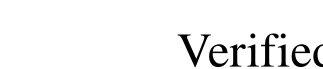

In [6]:
"""Render the NetworkX derivation DAG with Graphviz."""


def render_derivation_graph(nx_graph, selected_path):
    """Convert a NetworkX derivation DAG into a Graphviz SVG.

    Args:
        nx_graph: Directed NetworkX graph containing derivation metadata.
        selected_path: Ordered selected-path dictionaries returned by the
            search engine.

    Returns:
        Graphviz Digraph containing the rendered derivation network.
    """
    selected_keys = [step["key"] for step in selected_path]
    selected_nodes = set(selected_keys)
    selected_edges = set(zip(selected_keys[:-1], selected_keys[1:]))

    dot = graphviz.Digraph(
        name="derivation_dag",
        format="svg",
        engine="dot",
    )
    dot.attr(
        rankdir=GRAPHVIZ_RANKDIR,
        dpi=str(GRAPHVIZ_DPI),
        splines="spline",
        overlap="false",
        concentrate="false",
        nodesep="0.35",
        ranksep="0.70",
        labelloc="t",
        label="Verified Mathematical Derivation DAG",
    )
    dot.attr(
        "node",
        fontname="Helvetica",
        fontsize="9",
        margin="0.08,0.05",
    )
    dot.attr(
        "edge",
        fontname="Helvetica",
        fontsize="8",
        arrowsize="0.7",
    )

    node_ids = {key: f"n{index}" for index, key in enumerate(nx_graph.nodes)}

    for key, data in nx_graph.nodes(data=True):
        expression_text = sp.sstr(data["expr"])
        if len(expression_text) > GRAPHVIZ_MAX_LABEL_CHARS:
            expression_text = (
                expression_text[: GRAPHVIZ_MAX_LABEL_CHARS - 1] + "…"
            )

        label = (
            f"{expression_text}\n"
            f"depth={data['depth']} | "
            f"score={data['score_total']:.3f}\n"
            f"{data['verification']}"
        )

        if key in selected_nodes:
            dot.node(
                node_ids[key],
                label=label,
                shape="box",
                penwidth="2.4",
            )
        else:
            dot.node(
                node_ids[key],
                label=label,
                shape="ellipse",
                penwidth="0.9",
            )

    for source, target, data in nx_graph.edges(data=True):
        edge_key = (source, target)
        if edge_key in selected_edges:
            dot.edge(
                node_ids[source],
                node_ids[target],
                label=data["rule"],
                penwidth="2.4",
            )
        else:
            dot.edge(
                node_ids[source],
                node_ids[target],
                label=data["rule"],
                style="dashed",
                penwidth="0.8",
            )

    return dot


graph = poly_result["graph"]
derivation_dot = render_derivation_graph(
    graph,
    poly_result["selected_path"],
)

try:
    derivation_svg = derivation_dot.pipe(format="svg")
except graphviz.backend.ExecutableNotFound:
    from io import BytesIO
    import matplotlib.pyplot as plt

    fallback_figure, fallback_axis = plt.subplots(figsize=(10, 5), dpi=250)
    positions = nx.multipartite_layout(graph, subset_key="depth")
    labels = {key: f"E{index}" for index, key in enumerate(graph)}
    nx.draw_networkx(graph, positions, labels=labels, ax=fallback_axis)
    fallback_axis.set_axis_off()
    fallback_buffer = BytesIO()
    fallback_figure.savefig(fallback_buffer, format="svg", bbox_inches="tight")
    derivation_svg = fallback_buffer.getvalue()
    plt.close(fallback_figure)
    print("Graphviz executable unavailable; rendered with Matplotlib.")
display(SVG(derivation_svg))

# Keep the DOT representation available for reproducible external rendering.
DERIVATION_DOT_SOURCE = derivation_dot.source

## Demonstration 2: trigonometric identity derivation

The target is structurally different from the starting expression, so the search records a transformation path instead of stopping merely because the two expressions are mathematically equivalent.

In [7]:
"""Derive a standard trigonometric identity."""

TRIG_START = sp.sin(x) ** 2 + sp.cos(x) ** 2
TRIG_TARGET = sp.Integer(1)

trig_result = search_derivation(
    start_expr=TRIG_START,
    target=TRIG_TARGET,
    objective={"kind": "exact_target"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES + ("expand_trig",),
    search_mode="best_first",
    context={"collect_symbol": x},
)

assert sp.srepr(trig_result["selected_path"][-1]["expr"]) == sp.srepr(TRIG_TARGET)

for index, step in enumerate(trig_result["selected_path"]):
    label = "start" if index == 0 else step["rule"]
    print(f"{index:>2}: {label:<12} {sp.sstr(step['expr'])}")

 0: start        sin(x)**2 + cos(x)**2
 1: trigsimp     1


## Demonstration 3: objective-driven derivation without an exact target

Here the engine receives `{"kind": "factor"}` instead of a target. Completion means the current expression is already in the structural form returned by `SymPy.factor`.

In [8]:
"""Search for a factorized canonical form without specifying a target."""

OBJECTIVE_START = x**4 - 5 * x**2 + 4

objective_result = search_derivation(
    start_expr=OBJECTIVE_START,
    target=None,
    objective={"kind": "factor"},
    symbols=(x,),
    rule_registry=RULE_REGISTRY,
    permitted_rules=PERMITTED_RULES,
    search_mode="astar",
    context={"collect_symbol": x},
)

objective_terminal = objective_result["selected_path"][-1]["expr"]
assert sp.srepr(objective_terminal) == sp.srepr(sp.factor(objective_terminal))

display(
    Math(
        rf"{sp.latex(OBJECTIVE_START)}"
        rf"\longrightarrow {sp.latex(objective_terminal)}"
    )
)

<IPython.core.display.Math object>

## Clifford algebra and graded algebra

For an orthogonal basis, the Clifford relations are

$$
e_i e_j + e_j e_i = 2g_{ij},
$$

and in the diagonal case

$$
e_i^2=Q(e_i).
$$

The canonical reducer below sorts basis indices, tracks the parity of transpositions, and collapses repeated basis elements into metric factors. A homogeneous Clifford word has $\mathbb Z/2\mathbb Z$ grade equal to its word length modulo two.

For homogeneous graded factors, the tensor-product multiplication uses the Koszul sign

$$
(x_1\otimes x_2)(y_1\otimes y_2)
=
(-1)^{|x_2||y_1|}(x_1y_1)\otimes(x_2y_2).
$$

In [9]:
"""Implement Clifford canonical reduction and the Koszul sign rule."""


def reduce_clifford_word(word, diagonal_metric):
    """Reduce an orthogonal Clifford word to canonical ordered form.

    Args:
        word: Iterable of integer basis indices.
        diagonal_metric: Mapping i -> Q(e_i) = g_ii.

    Returns:
        Dictionary with coefficient, canonical word, and Z/2Z grade.
    """
    word = tuple(word)
    inversions = sum(
        left > right
        for index, left in enumerate(word)
        for right in word[index + 1 :]
    )
    coefficient = sp.Integer(-1) ** inversions
    counts = Counter(word)
    canonical = []

    for basis_index in sorted(counts):
        if basis_index not in diagonal_metric:
            raise KeyError(f"Missing Q(e_{basis_index}) in the metric.")
        count = counts[basis_index]
        coefficient *= sp.sympify(diagonal_metric[basis_index]) ** (count // 2)
        if count % 2:
            canonical.append(basis_index)

    return {
        "coefficient": sp.simplify(coefficient),
        "word": tuple(canonical),
        "grade": len(canonical) % 2,
    }


def graded_tensor_product(left, right):
    """Multiply homogeneous tensor factors using the Koszul sign rule.

    Args:
        left: Tuple ((x1, grade_x1), (x2, grade_x2)).
        right: Tuple ((y1, grade_y1), (y2, grade_y2)).

    Returns:
        Dictionary containing the Koszul sign and resulting graded factors.
    """
    (x1, grade_x1), (x2, grade_x2) = left
    (y1, grade_y1), (y2, grade_y2) = right
    sign = (-1) ** (grade_x2 * grade_y1)
    return {
        "sign": sign,
        "left_factor": x1 * y1,
        "right_factor": x2 * y2,
        "grades": (
            (grade_x1 + grade_y1) % 2,
            (grade_x2 + grade_y2) % 2,
        ),
    }


NEGATIVE_METRIC = {1: -1, 2: -1, 3: -1, 4: -1}
CLIFFORD_WORD = (3, 1, 2, 1, 3)
clifford_result = reduce_clifford_word(CLIFFORD_WORD, NEGATIVE_METRIC)

print("Input word:", CLIFFORD_WORD)
print("Coefficient:", clifford_result["coefficient"])
print("Canonical word:", clifford_result["word"])
print("Z/2Z grade:", clifford_result["grade"])

# The objective "clifford_canonical" is fulfilled by this domain adapter.
CLIFFORD_OBJECTIVE = {"kind": "clifford_canonical"}
assert clifford_result["word"] == tuple(sorted(clifford_result["word"]))

# Compact Koszul-sign demonstration: |x2| = |y1| = 1 gives a minus sign.
a, b, c, d = sp.symbols("a b c d", commutative=False)
koszul_result = graded_tensor_product(
    ((a, 0), (b, 1)),
    ((c, 1), (d, 0)),
)
print("Koszul sign:", koszul_result["sign"])
assert koszul_result["sign"] == -1

Input word: (3, 1, 2, 1, 3)
Coefficient: 1
Canonical word: (2,)
Z/2Z grade: 1
Koszul sign: -1


## Reusable Poincaré and graded-series bookkeeping

For an exact decomposition

$$
H(q)=A(q)X(q)+B(q)Y(q)+Z(q),
$$

the unknown component $X(q)$ can be recovered by exact polynomial division whenever the problem is well posed. A zero remainder certifies exact reconstruction in the polynomial ring.

In [10]:
"""Recover an unknown exact graded component and verify reconstruction."""


def recover_graded_component(h_poly, a_poly, b_poly, y_poly, z_poly, variable):
    """Recover X from H = A*X + B*Y + Z by exact polynomial division.

    Args:
        h_poly: Known total graded polynomial H.
        a_poly: Known multiplier A.
        b_poly: Known multiplier B.
        y_poly: Known graded component Y.
        z_poly: Known residual component Z.
        variable: Polynomial grading variable.

    Returns:
        Dictionary with quotient, remainder, and reconstruction status.
    """
    numerator = sp.Poly(
        sp.expand(h_poly - b_poly * y_poly - z_poly),
        variable,
        domain=sp.QQ,
    )
    denominator = sp.Poly(a_poly, variable, domain=sp.QQ)
    quotient, remainder = sp.div(numerator, denominator)
    recovered = quotient.as_expr()
    reconstructed = sp.expand(
        a_poly * recovered + b_poly * y_poly + z_poly
    )
    exact = remainder.is_zero and sp.expand(reconstructed - h_poly) == 0
    return {
        "quotient": recovered,
        "remainder": remainder.as_expr(),
        "reconstructed": reconstructed,
        "exact": bool(exact),
    }


q = sp.symbols("q")
A_Q = 1 + q + q**2
B_Q = 1 + q**2
X_TRUE = 1 + q**3 + q**5
Y_Q = q + q**4
Z_Q = q**7
H_Q = sp.expand(A_Q * X_TRUE + B_Q * Y_Q + Z_Q)

series_result = recover_graded_component(H_Q, A_Q, B_Q, Y_Q, Z_Q, q)

display(Math(rf"H(q)={sp.latex(H_Q)}"))
display(Math(rf"X(q)={sp.latex(series_result['quotient'])}"))
display(Math(rf"R(q)={sp.latex(series_result['remainder'])}"))

assert series_result["exact"]
assert sp.expand(series_result["quotient"] - X_TRUE) == 0

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Independent Z3 counterexample rejection

For supported polynomial expressions, the verifier asks whether a real or integer assignment satisfying the assumptions can make the residual nonzero. `unsat` means Z3 has rejected all such counterexamples within the encoded theory.

In [11]:
"""Demonstrate SMT verification of a polynomial identity."""

Z3_LHS = (x + 1) ** 2
Z3_RHS = x**2 + 2 * x + 1
z3_check = verify_equivalence(Z3_LHS, Z3_RHS, (x,))

print(z3_check)
assert z3_check["proved"]
assert z3_check["status"] in ("exact_symbolic", "smt_verified")

# Force the explicit Z3 route with an independently constructed solver.
zx = z3.Real("zx")
solver = z3.Solver()
solver.add((zx + 1) * (zx + 1) != zx * zx + 2 * zx + 1)
assert solver.check() == z3.unsat
print("Explicit Z3 counterexample search: unsat")

{'status': 'exact_symbolic', 'proved': True, 'mpmath_ok': True, 'cupy_ok': True, 'max_error': 0.0}
Explicit Z3 counterexample search: unsat


## CuPy batched numerical consistency check

This section performs a large CUDA batch independently of SymPy's exact result. It is useful for stress testing transformations over many admissible points. It remains a numerical consistency test, regardless of sample count.

In [12]:
"""Run an explicit CuPy batched numerical identity check on the GPU."""

if GPU_AVAILABLE:
    rng = cp.random.RandomState(RANDOM_SEED)
    x_gpu = rng.uniform(0.125, 3.0, size=GPU_SAMPLES)
    lhs_gpu = (x_gpu + 1.0) ** 4
    rhs_gpu = (
        x_gpu**4
        + 4.0 * x_gpu**3
        + 6.0 * x_gpu**2
        + 4.0 * x_gpu
        + 1.0
    )
    gpu_max_error = float(cp.max(cp.abs(lhs_gpu - rhs_gpu)).get())
    print(f"CuPy samples: {GPU_SAMPLES:,}")
    print(f"Maximum absolute residual: {gpu_max_error:.3e}")
    assert gpu_max_error <= 1e-9
else:
    print(
        "No CUDA device is active. In Google Colab, select a GPU runtime "
        "to execute the CuPy verification section."
    )

CuPy samples: 32,768
Maximum absolute residual: 5.684e-14


## LaTeX export

The selected polynomial path is exported as an `align` environment suitable for Overleaf. Transformation labels remain attached to individual steps.

In [13]:
"""Export the selected derivation as an Overleaf-ready LaTeX align block."""

latex_lines = [r"\begin{align}"]
for index, step in enumerate(poly_result["selected_path"]):
    expression_latex = sp.latex(step["expr"])
    if index == 0:
        latex_lines.append(rf"E_0 &= {expression_latex} \\")
    else:
        latex_lines.append(
            rf"E_{index} &= {expression_latex} "
            rf"\qquad \text{{[{step['rule']}]}} \\"
        )
latex_lines.append(r"\end{align}")

latex_derivation = "\n".join(latex_lines)
print(latex_derivation)

\begin{align}
E_0 &= x^{4} + 4 x^{3} + 6 x^{2} + 4 x + 1 \\
E_1 &= \left(x + 1\right)^{4} \qquad \text{[factor]} \\
\end{align}


## Extension data model

The current implementation keeps topology-specific components outside the core search so they can later use a SageMath backend without changing the symbolic search API.

```text
Automated Mathematical Derivation Engine
│
├── Symbolic algebra
│   ├── exact rewrites
│   ├── objective-driven search
│   └── assumptions
│
├── Verification
│   ├── SymPy exact checks
│   ├── Z3 SMT checks
│   ├── mpmath high-precision checks
│   └── CuPy batched GPU checks
│
├── Derivation graph
│   ├── competing branches
│   ├── transparent scoring
│   ├── pruning
│   └── ranked paths
│
├── Clifford algebra
│   ├── canonical words
│   ├── metric factors
│   ├── Z/2Z grading
│   └── Koszul signs
│
├── Graded algebra
│   ├── graded tensor products
│   ├── modules
│   └── chain complexes
│
├── Exact sequences
│   ├── kernels
│   ├── images
│   ├── quotient objects
│   └── exactness checks
│
└── Optional SageMath backend
    ├── groups
    ├── rings and modules
    ├── Clifford algebras
    ├── Steenrod algebra
    ├── chain complexes
    ├── homology and cohomology
    └── selected bordism computations
```

The schema below records these future interfaces without importing SageMath in the Colab runtime.

In [14]:
"""Declare extension interfaces for later algebraic-topology backends."""

EXTENSION_SCHEMA = {
    "graded_module": {
        "ring": None,
        "generators": [],
        "degrees": {},
        "relations": [],
    },
    "chain_complex": {
        "chain_groups": {},
        "boundary_maps": {},
        "coefficient_ring": None,
    },
    "exact_sequence": {
        "objects": [],
        "maps": [],
        "kernels": {},
        "images": {},
        "exactness": {},
    },
    "sage_backend": {
        "enabled": False,
        "capabilities": (
            "groups",
            "rings",
            "modules",
            "steenrod_algebra",
            "homology",
            "cohomology",
            "bordism_bookkeeping",
        ),
    },
}

print(EXTENSION_SCHEMA["sage_backend"])

{'enabled': False, 'capabilities': ('groups', 'rings', 'modules', 'steenrod_algebra', 'homology', 'cohomology', 'bordism_bookkeeping')}


## Lightweight integrity checks

The notebook already asserts the principal demonstrations. The checks below confirm graph acyclicity, path verification metadata, exact polynomial reconstruction, and Clifford canonical ordering.

In [15]:
"""Run compact integrity checks across the notebook."""

assert nx.is_directed_acyclic_graph(poly_result["graph"])
assert all(
    poly_result["graph"].edges[source, target]["verification"]
    in ("exact_symbolic", "smt_verified", "numerically_consistent")
    for source, target in poly_result["graph"].edges
)
assert series_result["exact"]
assert clifford_result["word"] == tuple(sorted(clifford_result["word"]))
assert koszul_result["sign"] == -1
assert candidate_table.shape[0] >= 1
assert "digraph" in DERIVATION_DOT_SOURCE
assert len(derivation_svg) > 0

print("All integrity checks passed.")

All integrity checks passed.


# Demonstration 4: Ehrenfest's theorem

Deriving Ehrenfest's theorem connects quantum state evolution to the average motion of a particle. Across an extended wavepacket, the average force generally differs from the force at the mean position, making the packet's spread part of the dynamics. A harmonic force closes the equations for the center exactly; a quartic potential exposes the additional contribution from spatial moments [1].

## Prerequisites and mathematical assumptions

A ket represents a state vector, and its adjoint bra forms expectation values with operators. Differentiating that pairing requires regularity of the state as well as a common domain for the ordered operator products. The declared assumptions are mathematical inputs, separate from the algebra checked by SymPy.

For a normalized state $|\psi(t)\rangle$ and observable $\hat A(t)$, define the **expectation value** by

$$
\langle\hat A\rangle:=\langle\psi|\hat A|\psi\rangle.
$$

With $\hat H$ denoting a self-adjoint Hamiltonian and $\hbar$ the reduced Planck constant, assume Schrödinger evolution,

$$
i\hbar|\dot\psi\rangle=\hat H|\psi\rangle.
$$

The identity to be proved is

$$
\frac{d}{dt}\langle\hat A\rangle
=\frac{1}{i\hbar}\langle[\hat A,\hat H]\rangle
+\langle\partial_t\hat A\rangle.
$$

All state derivatives and displayed products must exist on a common invariant domain. The symbolic search proves conditional algebraic equivalence; it supplies neither a proof of these analytic assumptions nor a proof-assistant certificate.

## Conceptual motivation

Both bra and ket evolve, producing two Hamiltonian terms with opposite signs. Preserving their operator order yields the commutator, which governs the average's response to the Hamiltonian. By accepting an operator verifier through a callback, the existing search function retains the scalar examples and their original rule registry.

Registered operator rules encode the physical identities supplied here. Search explores these admissible rewrites; specifically, this is a worked rule-based derivation where Schrödinger dynamics are supplied as an assumption rather than discovered automatically. While the legacy astar option uses a heuristic score without an optimality guarantee, this example employs breadth-first search.

In [16]:
"""Configure the Ehrenfest derivation, numerical benchmarks, and exports."""

from io import BytesIO
from pathlib import Path
import json
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from sympy.physics.quantum import Commutator
from IPython.display import Image, Markdown, FileLink

# - Control knobs ------------------------------------------------------------
EH_SEARCH_MODE = "breadth_first"
EH_USE_GPU = True
EH_BASIS_SIZE = 64
EH_CHECK_BASIS_SIZE = 96
EH_TIME_STOP = 8.0
EH_TIME_POINTS = 401
EH_QUARTIC_STRENGTH = 0.05
EH_INITIAL_POSITION = 1.5
EH_INITIAL_MOMENTUM = 0.0
EH_DERIVATIVE_STEPS = (0.08, 0.04, 0.02, 0.01)
EH_DPI = 250
EH_OUTPUT_DIRECTORY = Path("ehrenfest_outputs")
EH_DOWNLOAD_ZIP = False

# - Assumptions are inputs, beyond symbolic proof -----------------------------
EH_ASSUMPTIONS = {
    "normalized_state": True,
    "self_adjoint_hamiltonian": True,
    "schrodinger_evolution": True,
    "differentiable_matrix_elements": True,
    "common_invariant_domain": True,
}

plt.rcParams.update({"figure.dpi": EH_DPI, "savefig.dpi": EH_DPI})
EH_XP = cp if EH_USE_GPU and GPU_AVAILABLE else np
EH_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
assert EH_CHECK_BASIS_SIZE > EH_BASIS_SIZE >= 12
assert EH_TIME_POINTS >= 5 and EH_TIME_STOP > 0
assert EH_QUARTIC_STRENGTH >= 0
print("Numerical backend:", "CuPy" if EH_XP is cp else "NumPy")


Numerical backend: CuPy


## Ordered expressions and conditional rules

A change in operator order changes the physical result, making scalar sampling unsuitable for the symbolic identity. The verifier expands both expressions into the same ordered words and tests their exact difference [2]. A deliberately reversed sign provides a rejection test.

In the formal representation, `bra` and `ket` mark the endpoints of a matrix element. The symbol `Adot` represents the observable's own time derivative, and `Expect` wraps an expectation value. These formal words encode ordered algebra; the declared Hilbert-space assumptions provide their physical interpretation.

The product rule supplies three contributions,

$$
\frac{d}{dt}\langle\hat A\rangle
=\langle\dot\psi|\hat A|\psi\rangle
+\langle\psi|\partial_t\hat A|\psi\rangle
+\langle\psi|\hat A|\dot\psi\rangle.
$$

Taking the adjoint of the assumed ket equation gives the bra equation,

$$
\langle\dot\psi|=\frac{i}{\hbar}\langle\psi|\hat H.
$$

Substitution and linear collection then determine the general commutator form. The rule registry includes an alternative branch with the Hamiltonian first in the commutator.


In [17]:
"""Register ordered Ehrenfest rewrites and verify them under declared assumptions."""

EH_HBAR = sp.Symbol("hbar", positive=True)
EH_A, EH_H, EH_AD = sp.symbols("A H Adot", commutative=False)
EH_BRA, EH_KET, EH_BD, EH_KD = sp.symbols(
    "bra ket bra_dot ket_dot", commutative=False
)
EH_EXPECT = sp.Function("Expect")
EH_DT = sp.Function("DtExpect")

EH_START = EH_DT(EH_A)
EH_PRODUCT = (
    EH_BD * EH_A * EH_KET + EH_BRA * EH_AD * EH_KET + EH_BRA * EH_A * EH_KD
)
EH_EVOLUTION = {
    EH_BD: sp.I * EH_BRA * EH_H / EH_HBAR,
    EH_KD: -sp.I * EH_H * EH_KET / EH_HBAR,
}
EH_SUBSTITUTED = sp.expand(EH_PRODUCT.xreplace(EH_EVOLUTION))
EH_COLLECTED = sp.I * EH_EXPECT(
    EH_H * EH_A - EH_A * EH_H
) / EH_HBAR + EH_EXPECT(EH_AD)
EH_ALTERNATIVE = sp.I * EH_EXPECT(
    Commutator(EH_H, EH_A)
) / EH_HBAR + EH_EXPECT(EH_AD)
EH_TARGET = EH_EXPECT(Commutator(EH_A, EH_H)) / (sp.I * EH_HBAR) + EH_EXPECT(
    EH_AD
)


def eh_normal_form(expression):
    """Expand declared evolution and expectations into ordered formal words."""
    expression = expression.xreplace({EH_START: EH_PRODUCT})
    expression = expression.replace(
        lambda item: isinstance(item, Commutator),
        lambda item: item.doit(),
    )
    expression = expression.replace(
        lambda item: item.func == EH_EXPECT,
        lambda item: EH_BRA * item.args[0] * EH_KET,
    )
    return sp.expand(expression.xreplace(EH_EVOLUTION))


def eh_verify(lhs, rhs, symbols=()):
    """Check exact ordered algebra conditional on the declared analytic inputs.

    Args:
        lhs: Expression entering a transformation.
        rhs: Proposed expression after the transformation.
        symbols: Compatibility argument for the existing search engine.

    Returns:
        Verification metadata with a residual and declared assumptions.
    """
    conditions_met = all(EH_ASSUMPTIONS.values())
    residual = sp.expand(eh_normal_form(lhs) - eh_normal_form(rhs))
    accepted = conditions_met and residual == 0
    return {
        "status": "exact_symbolic" if accepted else "failed",
        "proved": accepted,
        "scope": "ordered algebra conditional on declared assumptions",
        "assumptions": dict(EH_ASSUMPTIONS),
        "residual": sp.sstr(residual),
        "mpmath_ok": None,
        "cupy_ok": None,
        "max_error": 0.0 if accepted else math.inf,
    }


def eh_rule(source, destination, category):
    """Create one guarded transformation in the existing registry format."""
    return {
        "transform": lambda expression, context: destination,
        "guard": lambda expression, context: (
            expression == source and all(EH_ASSUMPTIONS.values())
        ),
        "cost": 1.0,
        "category": category,
    }


EH_RULES = {
    "product_rule": eh_rule(EH_START, EH_PRODUCT, "differentiation"),
    "state_evolution": eh_rule(EH_PRODUCT, EH_SUBSTITUTED, "dynamics"),
    "collect_expectations": eh_rule(EH_SUBSTITUTED, EH_COLLECTED, "linearity"),
    "introduce_commutator": eh_rule(EH_COLLECTED, EH_TARGET, "commutator"),
    "hamiltonian_first": eh_rule(EH_COLLECTED, EH_ALTERNATIVE, "commutator"),
    "reverse_commutator": eh_rule(EH_ALTERNATIVE, EH_TARGET, "commutator"),
}

assert eh_verify(EH_START, EH_TARGET)["proved"]
eh_wrong_sign = -EH_EXPECT(Commutator(EH_A, EH_H)) / (
    sp.I * EH_HBAR
) + EH_EXPECT(EH_AD)
assert eh_verify(EH_START, eh_wrong_sign)["status"] == "failed"
EH_ASSUMPTIONS["self_adjoint_hamiltonian"] = False
assert eh_verify(EH_START, EH_TARGET)["status"] == "failed"
EH_ASSUMPTIONS["self_adjoint_hamiltonian"] = True

eh_result = search_derivation(
    EH_START,
    target=EH_TARGET,
    rule_registry=EH_RULES,
    permitted_rules=tuple(EH_RULES),
    search_mode=EH_SEARCH_MODE,
    verifier=eh_verify,
)
assert eh_result["goal_keys"]
assert eh_result["selected_path"][-1]["expr"] == EH_TARGET
for index, step in enumerate(eh_result["selected_path"]):
    reason = step["rule"] or "given derivative"
    display(Markdown(f"**Expression {index}.** {reason.replace('_', ' ')}."))
    display(Math(rf"E_{{{index}}}:={sp.latex(step['expr'])}"))

eh_rows = []
for source, target, edge in eh_result["graph"].edges(data=True):
    check = eh_verify(
        eh_result["graph"].nodes[source]["expr"],
        eh_result["graph"].nodes[target]["expr"],
    )
    edge.update(scope=check["scope"], assumptions=check["assumptions"])
    eh_rows.append(
        {
            "rule": edge["rule"],
            "status": check["status"],
            "scope": check["scope"],
        }
    )
display(pd.DataFrame(eh_rows))


**Expression 0.** given derivative.

<IPython.core.display.Math object>

**Expression 1.** product rule.

<IPython.core.display.Math object>

**Expression 2.** state evolution.

...

**Expression 3.** collect expectations.

<IPython.core.display.Math object>

**Expression 4.** introduce commutator.

<IPython.core.display.Math object>

,rule,status,scope
0,product_rule,exact_symbolic,ordered algebra conditional on declared assump...
1,state_evolution,exact_symbolic,ordered algebra conditional on declared assump...
2,collect_expectations,exact_symbolic,ordered algebra conditional on declared assump...
3,introduce_commutator,exact_symbolic,ordered algebra conditional on declared assump...
4,hamiltonian_first,exact_symbolic,ordered algebra conditional on declared assump...


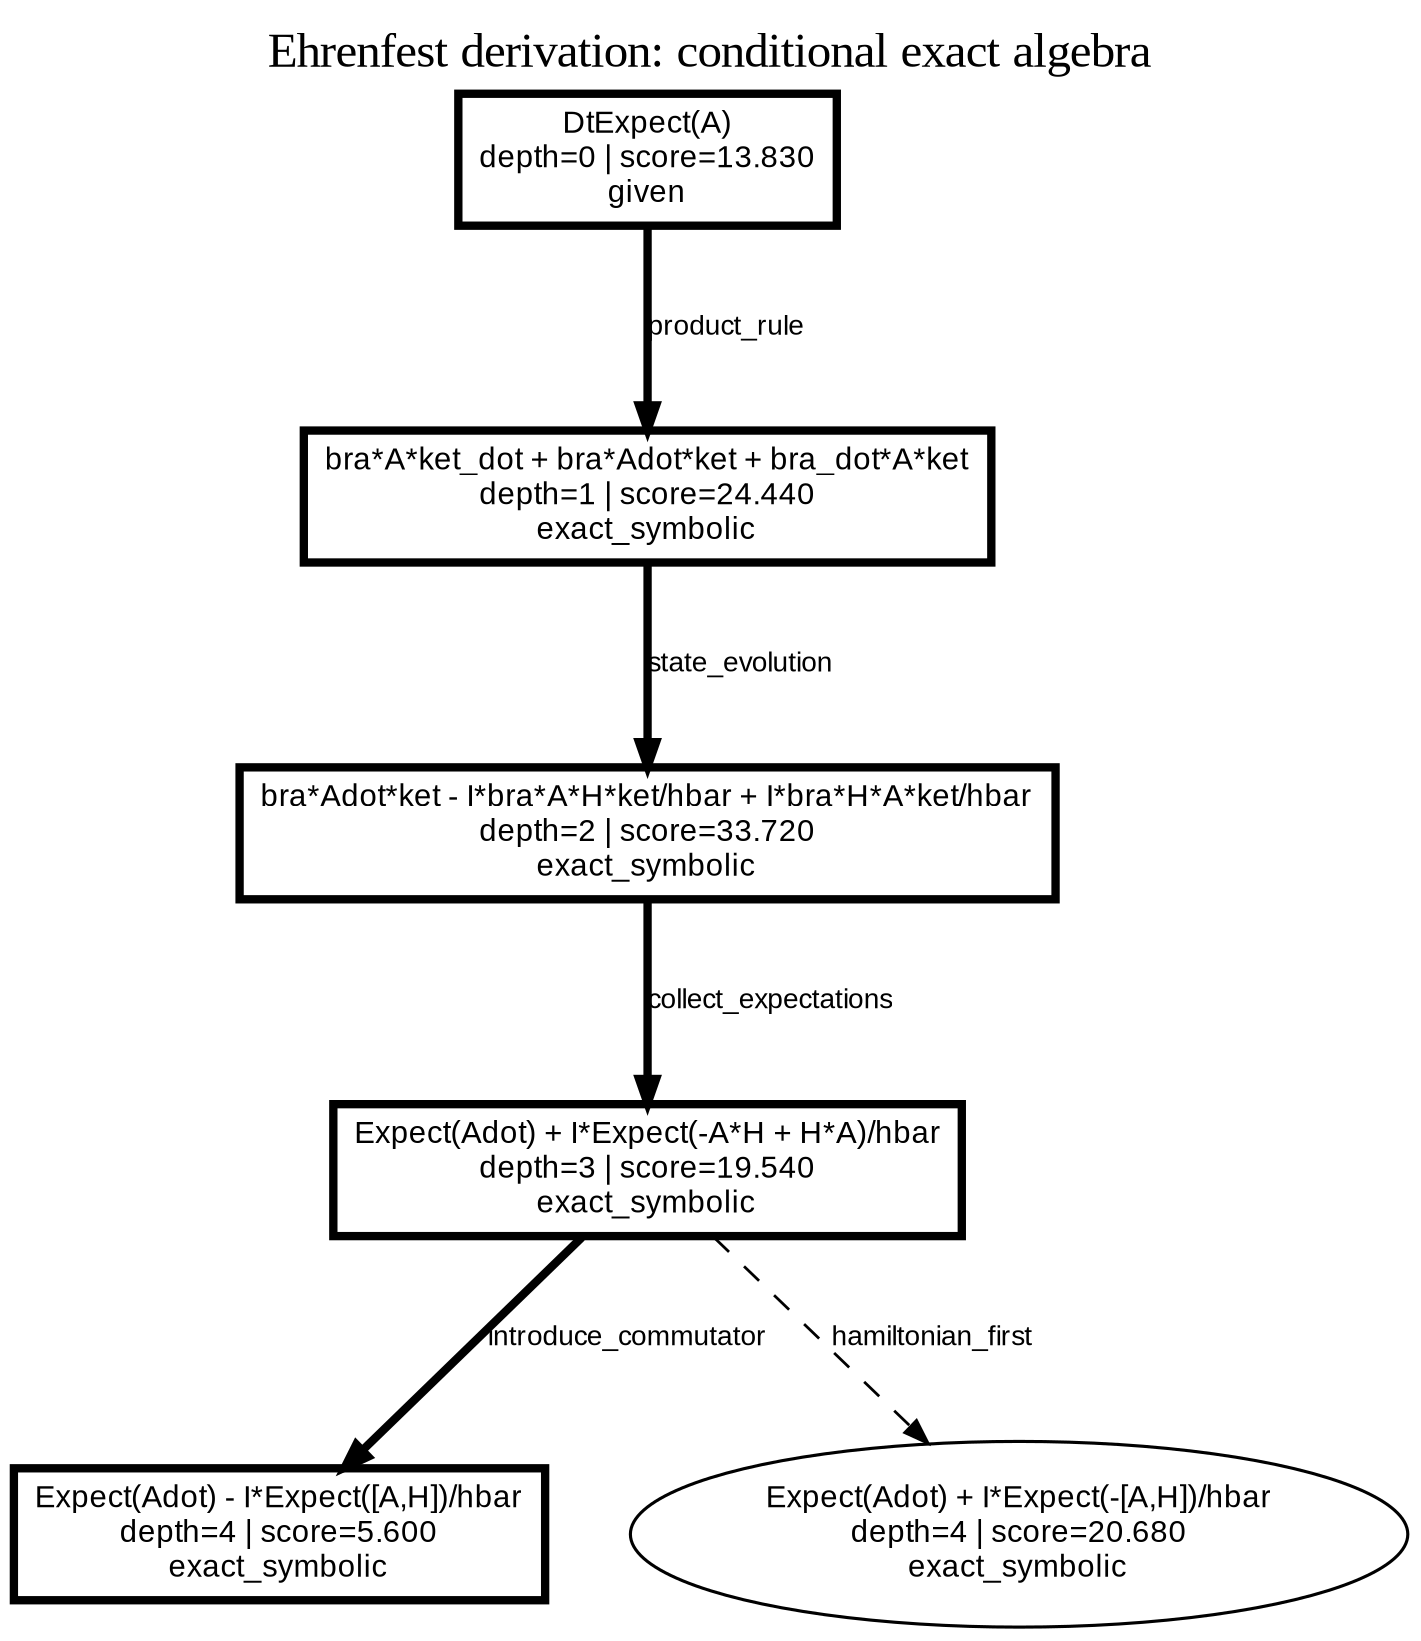

Sparse adjacency shape: (6, 6) stored edges: 5


In [18]:
"""Render the operator derivation and retain an in-memory PNG for export."""

eh_graph = eh_result["graph"]
eh_dot = render_derivation_graph(eh_graph, eh_result["selected_path"])
eh_dot.attr(
    rankdir="TB", label="Ehrenfest derivation: conditional exact algebra"
)
try:
    eh_graph_png = eh_dot.pipe(format="png")
except graphviz.backend.ExecutableNotFound:
    figure, axis = plt.subplots(figsize=(9, 8), dpi=EH_DPI)
    meanings = {
        EH_START: "Derivative of expectation",
        EH_PRODUCT: "Ordered product rule",
        EH_SUBSTITUTED: "Schrodinger substitution",
        EH_COLLECTED: "Collected expectations",
        EH_TARGET: "Observable-first commutator",
        EH_ALTERNATIVE: "Hamiltonian-first commutator",
    }
    positions = {}
    for depth in sorted(
        {data["depth"] for _, data in eh_graph.nodes(data=True)}
    ):
        keys = [
            key
            for key, data in eh_graph.nodes(data=True)
            if data["depth"] == depth
        ]
        offsets = np.linspace(-1.8, 1.8, len(keys)) if len(keys) > 1 else [0.0]
        for key, offset in zip(keys, offsets):
            positions[key] = (offset, -1.4 * depth)
    for index, (key, data) in enumerate(eh_graph.nodes(data=True)):
        axis.text(
            *positions[key],
            f"E{index}\n{meanings[data['expr']]}",
            ha="center",
            va="center",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.5",
                "facecolor": "white",
                "edgecolor": "black",
            },
        )
    for source, target, data in eh_graph.edges(data=True):
        start_x, start_y = positions[source]
        end_x, end_y = positions[target]
        axis.annotate(
            "",
            xy=(end_x, end_y + 0.22),
            xytext=(start_x, start_y - 0.22),
            arrowprops={"arrowstyle": "->", "color": "black"},
        )
        label_x = (start_x + end_x) / 2
        if start_x == end_x:
            label_x += 0.65
        axis.text(
            label_x,
            (start_y + end_y) / 2,
            data["rule"].replace("_", " "),
            fontsize=8,
            ha="left" if start_x == end_x else "center",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none"},
        )
    axis.set(
        xlim=(-3.5, 3.5),
        ylim=(-6.2, 0.6),
        title="Ehrenfest derivation under declared assumptions",
    )
    axis.set_axis_off()
    buffer = BytesIO()
    figure.savefig(buffer, format="png", bbox_inches="tight")
    eh_graph_png = buffer.getvalue()
    plt.close(figure)
display(Image(eh_graph_png))
eh_node_order = list(eh_graph)
eh_adjacency = nx.to_scipy_sparse_array(
    eh_graph, nodelist=eh_node_order, dtype=np.int8, format="csr"
)
print(
    "Sparse adjacency shape:",
    eh_adjacency.shape,
    "stored edges:",
    eh_adjacency.nnz,
)


## Position, momentum, and spatial moments

Momentum operates as a spatial derivative in the position representation. Acting this operator upon a potential-wavefunction product isolates the classical force term by canceling the wavefunction derivative between the two alternate operator orderings.

A physical system defined by a constant mass $m$ and a differentiable scalar potential $V$ relies on the Hamiltonian operator


$$\hat H:=\frac{\hat p^2}{2m}+V(\hat x).$$


Evaluating the differential representation of momentum against this scalar potential yields the fundamental commutation identity


$$[\hat p,V(\hat x)]\phi=-i\hbar V'(x)\phi.$$


This mathematical identity joins the canonical position commutator to determine the time evolution of the expected position


$$\frac{d}{dt}\langle\hat x\rangle=\frac{\langle\hat p\rangle}{m}.$$


The corresponding expectation value for momentum evolves according to the analogous dynamical equation


$$\frac{d}{dt}\langle\hat p\rangle=-\langle V'(\hat x)\rangle.$$

Characterizing the spatial distribution of the wavepacket necessitates defining the **mean position** as


$$\mu:=\langle\hat x\rangle.$$


Deviations from this expectation value quantify the physical spread of the state, yielding a **variance** of


$$\sigma_x^2:=\langle(\hat x-\mu)^2\rangle.$$


Higher-order asymmetries in the spatial distribution require the **third central moment**


$$\mu_3:=\langle(\hat x-\mu)^3\rangle.$$

Introducing a quartic contribution parameterized by the coefficient $\lambda$ to a standard harmonic potential yields an exact polynomial identity for the physical force discrepancy


$$\langle\hat F\rangle-F(\mu)=-12\lambda\mu\sigma_x^2-4\lambda\mu_3.$$


The purely harmonic components cancel identically from this difference to isolate the dynamical effects of the non-linear perturbation. Approximating this discrepancy for arbitrary smooth potentials necessitates a formal Taylor remainder bound. Such a polynomial benchmark terminates exactly to permit direct analytical evaluation without truncation errors.

In [19]:
"""Check canonical commutators and the quartic moment identity symbolically."""

eh_x = sp.Symbol("x", real=True)
eh_m = sp.Symbol("m", positive=True)
eh_phi = sp.Function("phi")(eh_x)
eh_v = sp.Function("V")(eh_x)


def eh_momentum(wavefunction):
    """Apply momentum to a sufficiently differentiable test wavefunction."""
    return -sp.I * EH_HBAR * sp.diff(wavefunction, eh_x)


xp_action = eh_x * eh_momentum(eh_phi) - eh_momentum(eh_x * eh_phi)
pv_action = eh_momentum(eh_v * eh_phi) - eh_v * eh_momentum(eh_phi)
assert sp.simplify(xp_action - sp.I * EH_HBAR * eh_phi) == 0
assert (
    sp.simplify(pv_action + sp.I * EH_HBAR * sp.diff(eh_v, eh_x) * eh_phi) == 0
)
kinetic_action = (
    eh_x * eh_momentum(eh_momentum(eh_phi))
    - eh_momentum(eh_momentum(eh_x * eh_phi))
) / (2 * eh_m)
assert (
    sp.simplify(kinetic_action - sp.I * EH_HBAR * eh_momentum(eh_phi) / eh_m)
    == 0
)
mu, delta, variance, moment_3, lam = sp.symbols(
    "mu delta variance moment_3 lambda", real=True
)
force_expanded = sp.Poly(-(mu + delta) - 4 * lam * (mu + delta) ** 3, delta)
central_moments = {0: 1, 1: 0, 2: variance, 3: moment_3}
force_average = sum(
    coefficient * central_moments[power[0]]
    for power, coefficient in force_expanded.terms()
)
force_at_mean = -mu - 4 * lam * mu**3
force_correction = sp.expand(force_average - force_at_mean)
assert (
    sp.expand(force_correction + 12 * lam * mu * variance + 4 * lam * moment_3)
    == 0
)
display(Math(r"\langle F\rangle-F(\mu)=" + sp.latex(force_correction)))
print("Canonical actions, kinetic commutator, and quartic moments passed.")


<IPython.core.display.Math object>

Canonical actions, kinetic commutator, and quartic moments passed.


## Numerical verification in oscillator units

Constructing a finite basis permits independent time evolution and measurement of the force correction. Truncated position and momentum matrices harbor a boundary defect within their canonical commutator, rendering basis convergence essential for extracting a physically valid continuum interpretation.

Adopting dimensionless oscillator units assigns a numerical value of unity to the reduced Planck constant, particle mass, and reference angular frequency. This scaling facilitates the definition of the numerical potential as


$$V(x):=\frac{x^2}{2}+\lambda x^4.$$

Preparing an initial coherent state fixes the mean position and momentum to match the initial classical trajectory, enforcing a harmonic-oscillator variance of one-half within the converged basis. Spectral propagation applies a Hermitian eigendecomposition [3] to eliminate numerical integration artifacts entirely within the boundaries of the selected finite Hamiltonian.

Assembling the finite Hamiltonian requires combining the diagonal harmonic energy with the fourth power of the truncated position matrix. Algebraic powers computed from a truncated matrix deviate mathematically from the projections of true continuum powers near the numerical cutoff. Extracting diagnostic metrics reports the resulting force residual and the probability occupation of the highest eight basis states, isolating these discrete spectral artifacts from the primary time-differentiation assessment by confirming agreement across two distinct basis sizes.

In [20]:
"""Propagate a coherent packet in harmonic and quartic potentials."""


def eh_to_numpy(array):
    """Return host data for plotting and diagnostics."""
    return cp.asnumpy(array) if EH_XP is cp else np.asarray(array)


def eh_simulate(size, quartic, times):
    """Solve a finite oscillator model by spectral propagation.

    Args:
        size: Number of oscillator basis functions.
        quartic: Nonnegative dimensionless quartic strength.
        times: One-dimensional array of dimensionless times.

    Returns:
        Host arrays of moments, forces, and finite-model diagnostics.
    """
    xp = EH_XP
    lowering = xp.diag(xp.sqrt(xp.arange(1, size, dtype=float)), 1)
    position = (lowering + lowering.T) / np.sqrt(2.0)
    momentum = -1j * (lowering - lowering.T) / np.sqrt(2.0)
    x2 = position @ position
    x3 = x2 @ position
    hamiltonian = xp.diag(xp.arange(size) + 0.5) + quartic * (x2 @ x2)
    force = -position - 4.0 * quartic * x3
    alpha = (EH_INITIAL_POSITION + 1j * EH_INITIAL_MOMENTUM) / np.sqrt(2.0)
    initial = np.empty(size, dtype=complex)
    initial[0] = np.exp(-(abs(alpha) ** 2) / 2)
    for index in range(1, size):
        initial[index] = initial[index - 1] * alpha / np.sqrt(index)
    initial /= np.linalg.norm(initial)
    energies, vectors = xp.linalg.eigh(hamiltonian)
    amplitudes = vectors.conj().T @ xp.asarray(initial)
    phase = xp.exp(-1j * energies[:, None] * xp.asarray(times)[None, :])
    states = vectors @ (amplitudes[:, None] * phase)

    def expectation(operator):
        """Evaluate a Hermitian operator across all propagated states."""
        return eh_to_numpy(
            xp.sum(states.conj() * (operator @ states), axis=0).real
        )

    mean_x = expectation(position)
    mean_p = expectation(momentum)
    second = expectation(x2)
    third = expectation(x3)
    variance_x = second - mean_x**2
    central_third = third - 3 * mean_x * second + 2 * mean_x**3
    force_mean = expectation(force)
    dp_commutator = expectation(
        -1j * (momentum @ hamiltonian - hamiltonian @ momentum)
    )
    dx_commutator = expectation(
        -1j * (position @ hamiltonian - hamiltonian @ position)
    )
    return {
        "t": np.asarray(times),
        "x": mean_x,
        "p": mean_p,
        "variance": variance_x,
        "third": central_third,
        "force": force_mean,
        "dp_commutator": dp_commutator,
        "force_at_mean": -mean_x - 4 * quartic * mean_x**3,
        "moment_correction": -12 * quartic * mean_x * variance_x
        - 4 * quartic * central_third,
        "force_residual": float(np.max(np.abs(dp_commutator - force_mean))),
        "velocity_residual": float(np.max(np.abs(dx_commutator - mean_p))),
        "tail": float(
            eh_to_numpy(xp.max(xp.sum(xp.abs(states[-8:]) ** 2, axis=0)))
        ),
        "norm_error": float(
            eh_to_numpy(
                xp.max(xp.abs(xp.sum(xp.abs(states) ** 2, axis=0) - 1))
            )
        ),
        "energy_drift": float(np.ptp(expectation(hamiltonian))),
    }


eh_times = np.linspace(0.0, EH_TIME_STOP, EH_TIME_POINTS)
eh_runs = {}
eh_diagnostics = []
for name, strength in (("Harmonic", 0.0), ("Quartic", EH_QUARTIC_STRENGTH)):
    low = eh_simulate(EH_BASIS_SIZE, strength, eh_times)
    high = eh_simulate(EH_CHECK_BASIS_SIZE, strength, eh_times)
    classical = solve_ivp(
        lambda time, state: (
            state[1],
            -state[0] - 4 * strength * state[0] ** 3,
        ),
        (0.0, EH_TIME_STOP),
        (EH_INITIAL_POSITION, EH_INITIAL_MOMENTUM),
        t_eval=eh_times,
        rtol=1e-10,
        atol=1e-12,
    )
    assert classical.success
    high["classical_x"] = classical.y[0]
    eh_runs[name] = high
    eh_diagnostics.append(
        {
            "potential": name,
            "basis_size": EH_CHECK_BASIS_SIZE,
            "basis_mean_x_difference": np.max(np.abs(low["x"] - high["x"])),
            "force_residual": high["force_residual"],
            "velocity_residual": high["velocity_residual"],
            "top_8_occupation": high["tail"],
            "norm_error": high["norm_error"],
            "energy_drift": high["energy_drift"],
        }
    )
eh_diagnostic_table = pd.DataFrame(eh_diagnostics)
display(eh_diagnostic_table)


,potential,basis_size,basis_mean_x_difference,force_residual,velocity_residual,top_8_occupation,norm_error,energy_drift
0,Harmonic,96,8.881784e-16,4.440892e-16,4.440892e-16,5.624207e-131,4.440892e-16,6.661338e-16
1,Quartic,96,7.389597e-08,8.677308e-10,4.440892e-16,1.762295e-11,1.554312e-15,1.820766e-14


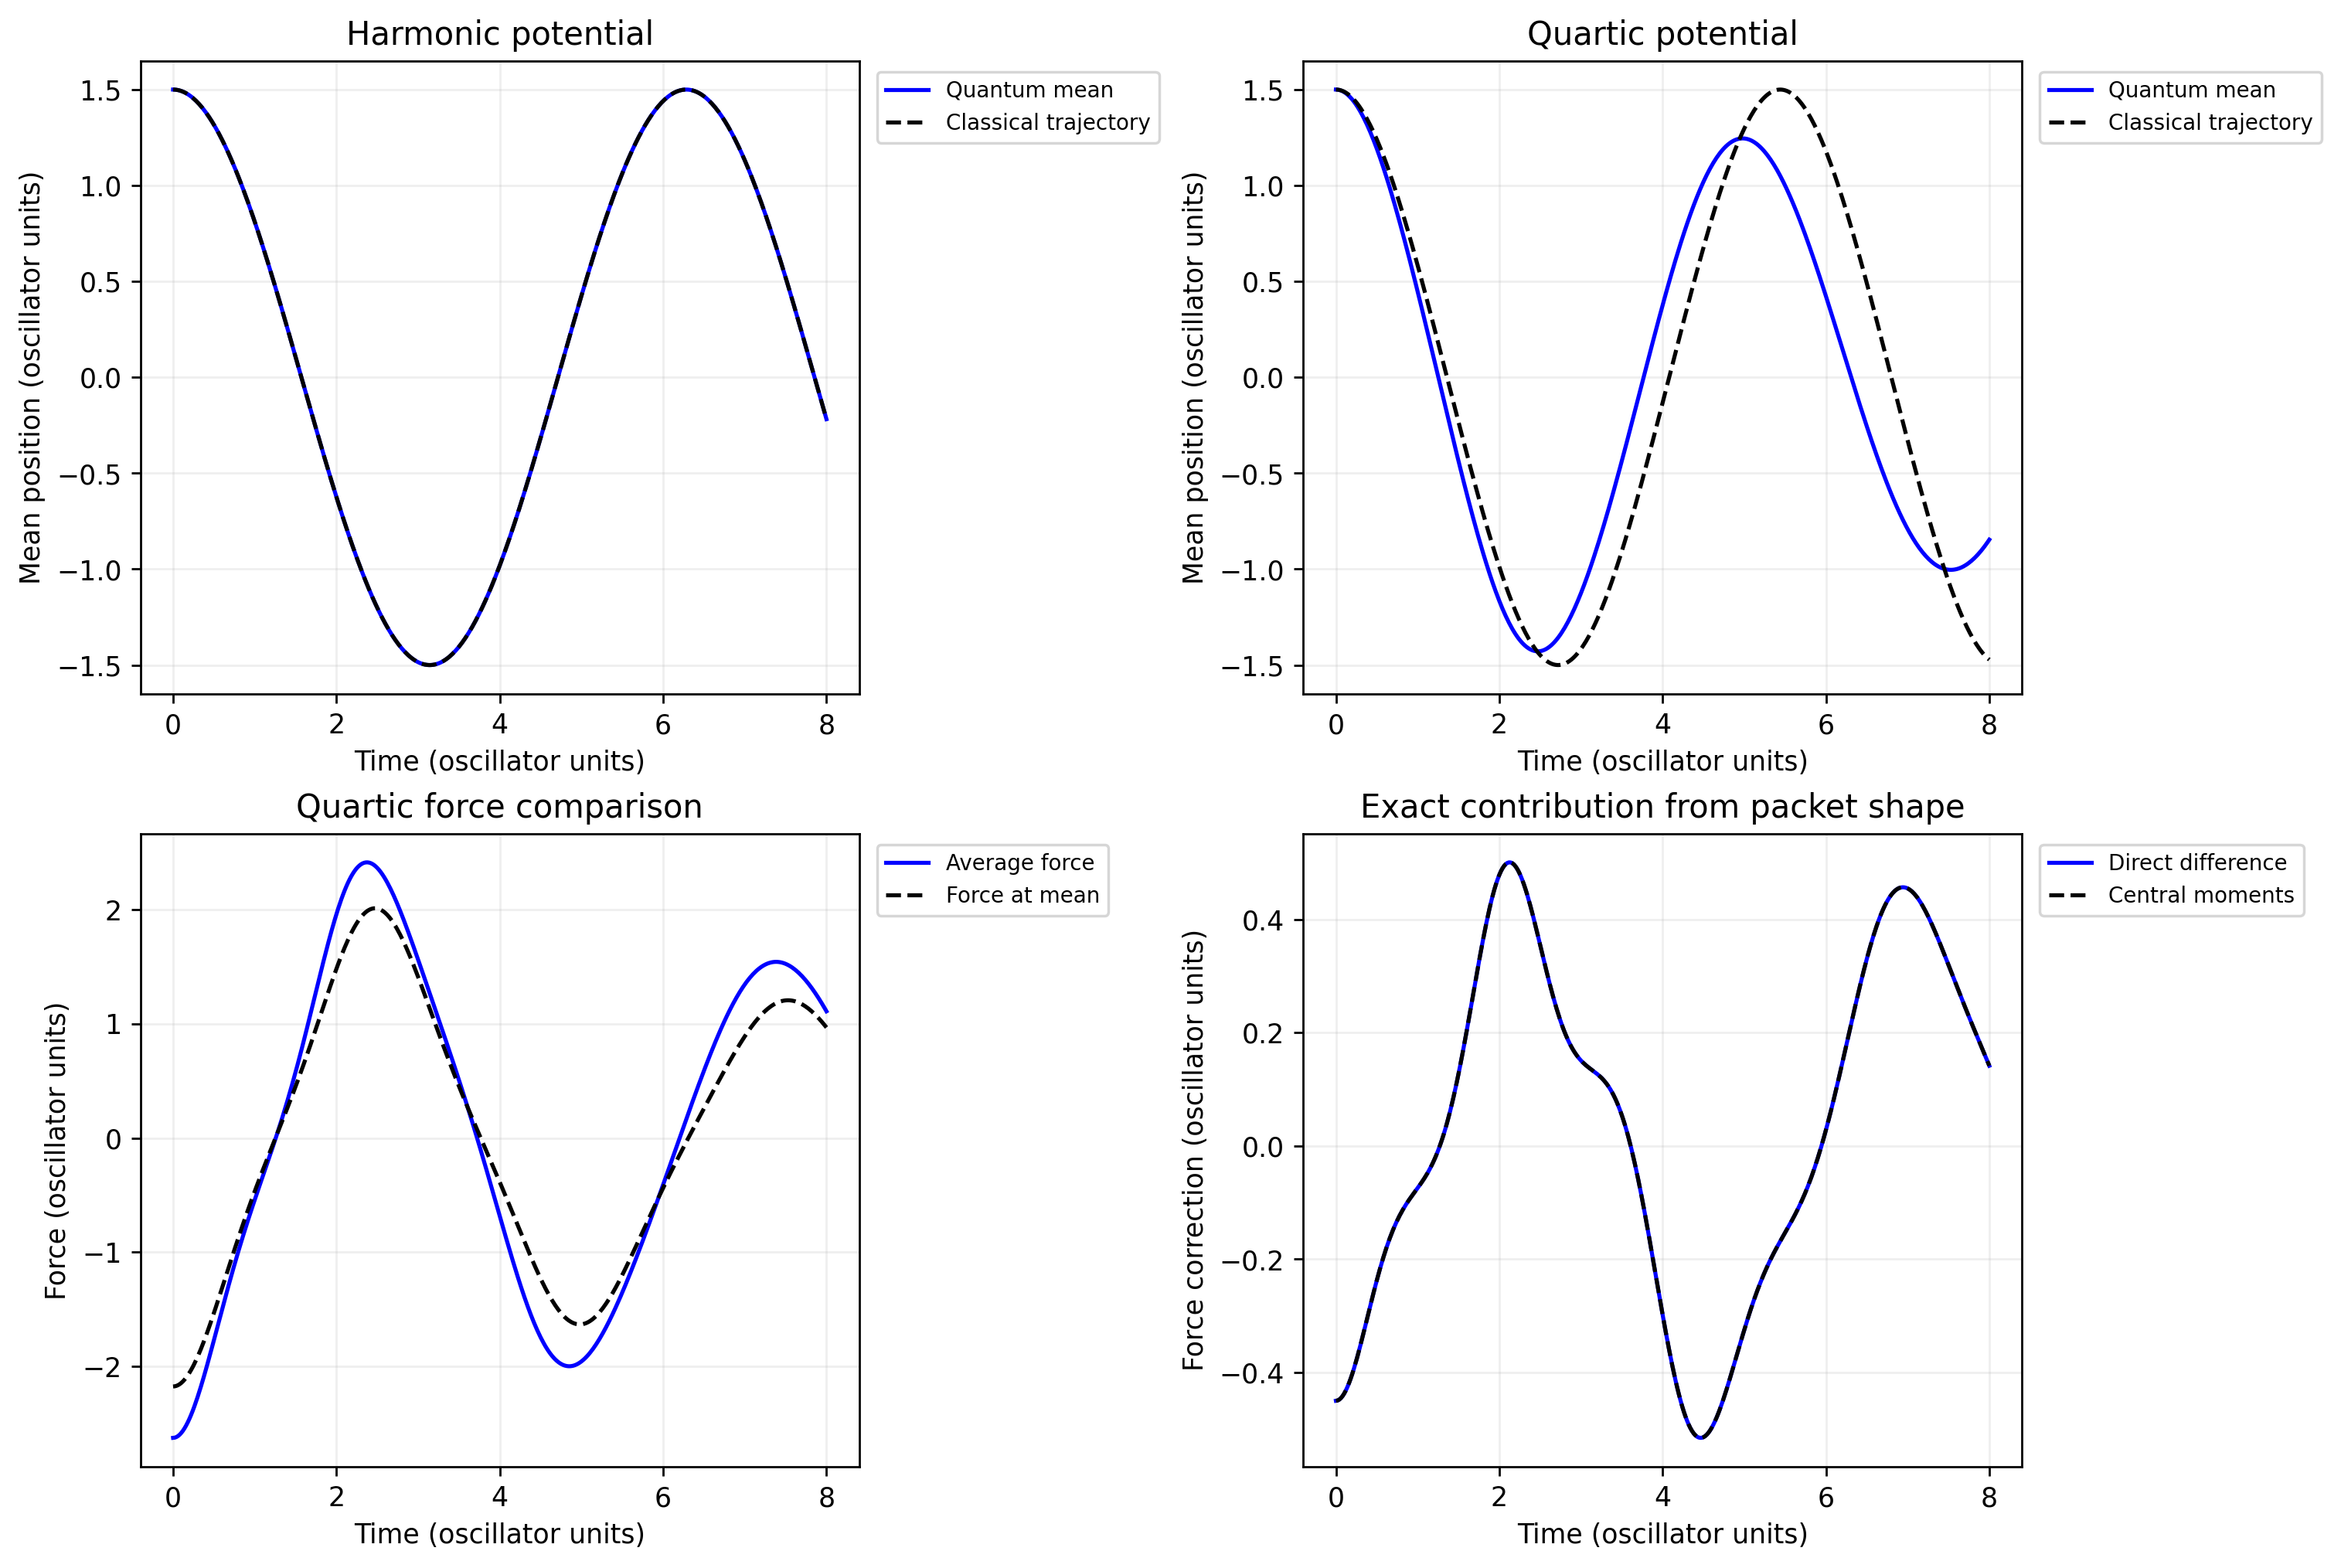

In [21]:
"""Plot centroid motion and the exact quartic correction in memory."""

figure, axes = plt.subplots(
    2, 2, figsize=(12, 8), dpi=EH_DPI, layout="constrained"
)
for axis, name in zip(axes[0], ("Harmonic", "Quartic")):
    run = eh_runs[name]
    axis.plot(run["t"], run["x"], color="#0000ff", label="Quantum mean")
    axis.plot(
        run["t"],
        run["classical_x"],
        "--",
        color="black",
        label="Classical trajectory",
    )
    axis.set(
        title=f"{name} potential",
        xlabel="Time (oscillator units)",
        ylabel="Mean position (oscillator units)",
    )
    axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
run = eh_runs["Quartic"]
axes[1, 0].plot(run["t"], run["force"], color="#0000ff", label="Average force")
axes[1, 0].plot(
    run["t"], run["force_at_mean"], "--", color="black", label="Force at mean"
)
axes[1, 0].set(
    title="Quartic force comparison",
    xlabel="Time (oscillator units)",
    ylabel="Force (oscillator units)",
)
axes[1, 1].plot(
    run["t"],
    run["force"] - run["force_at_mean"],
    color="#0000ff",
    label="Direct difference",
)
axes[1, 1].plot(
    run["t"],
    run["moment_correction"],
    "--",
    color="black",
    label="Central moments",
)
axes[1, 1].set(
    title="Exact contribution from packet shape",
    xlabel="Time (oscillator units)",
    ylabel="Force correction (oscillator units)",
)
for axis in axes[1]:
    axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
for axis in axes.flat:
    axis.grid(alpha=0.2)
plot_buffer = BytesIO()
figure.savefig(plot_buffer, format="png", bbox_inches="tight")
eh_motion_png = plot_buffer.getvalue()
plt.show()
plt.close(figure)


## Independent differentiation and integrity checks

Independent differentiation of a propagated expectation isolates the physical time dependence, introducing a quadratic leading error for smooth functions featuring nonzero cubic derivatives until arithmetic precision limits the evaluation. Parameterizing the momentum expectation $q(t)$ across a positive time increment $h$ yields the finite-difference expansion


$$\frac{q(t+h)-q(t-h)}{2h}=q'(t)+\frac{h^2}{6}q^{(3)}(t)+o(h^2).$$


The implemented numerical evaluation relies on the commutator derivative from the finite model, isolating the discrete force residual to assess agreement against the analytical continuum expression. Adjusting the integration controls necessitates expanding the selected basis dimensions to guarantee numerical stability, rendering the recorded convergence metrics essential for configuring the simulation accurately.

,time_increment,maximum_residual
0,0.08,0.007175
1,0.04,0.001798
2,0.02,0.000450
3,0.01,0.000112


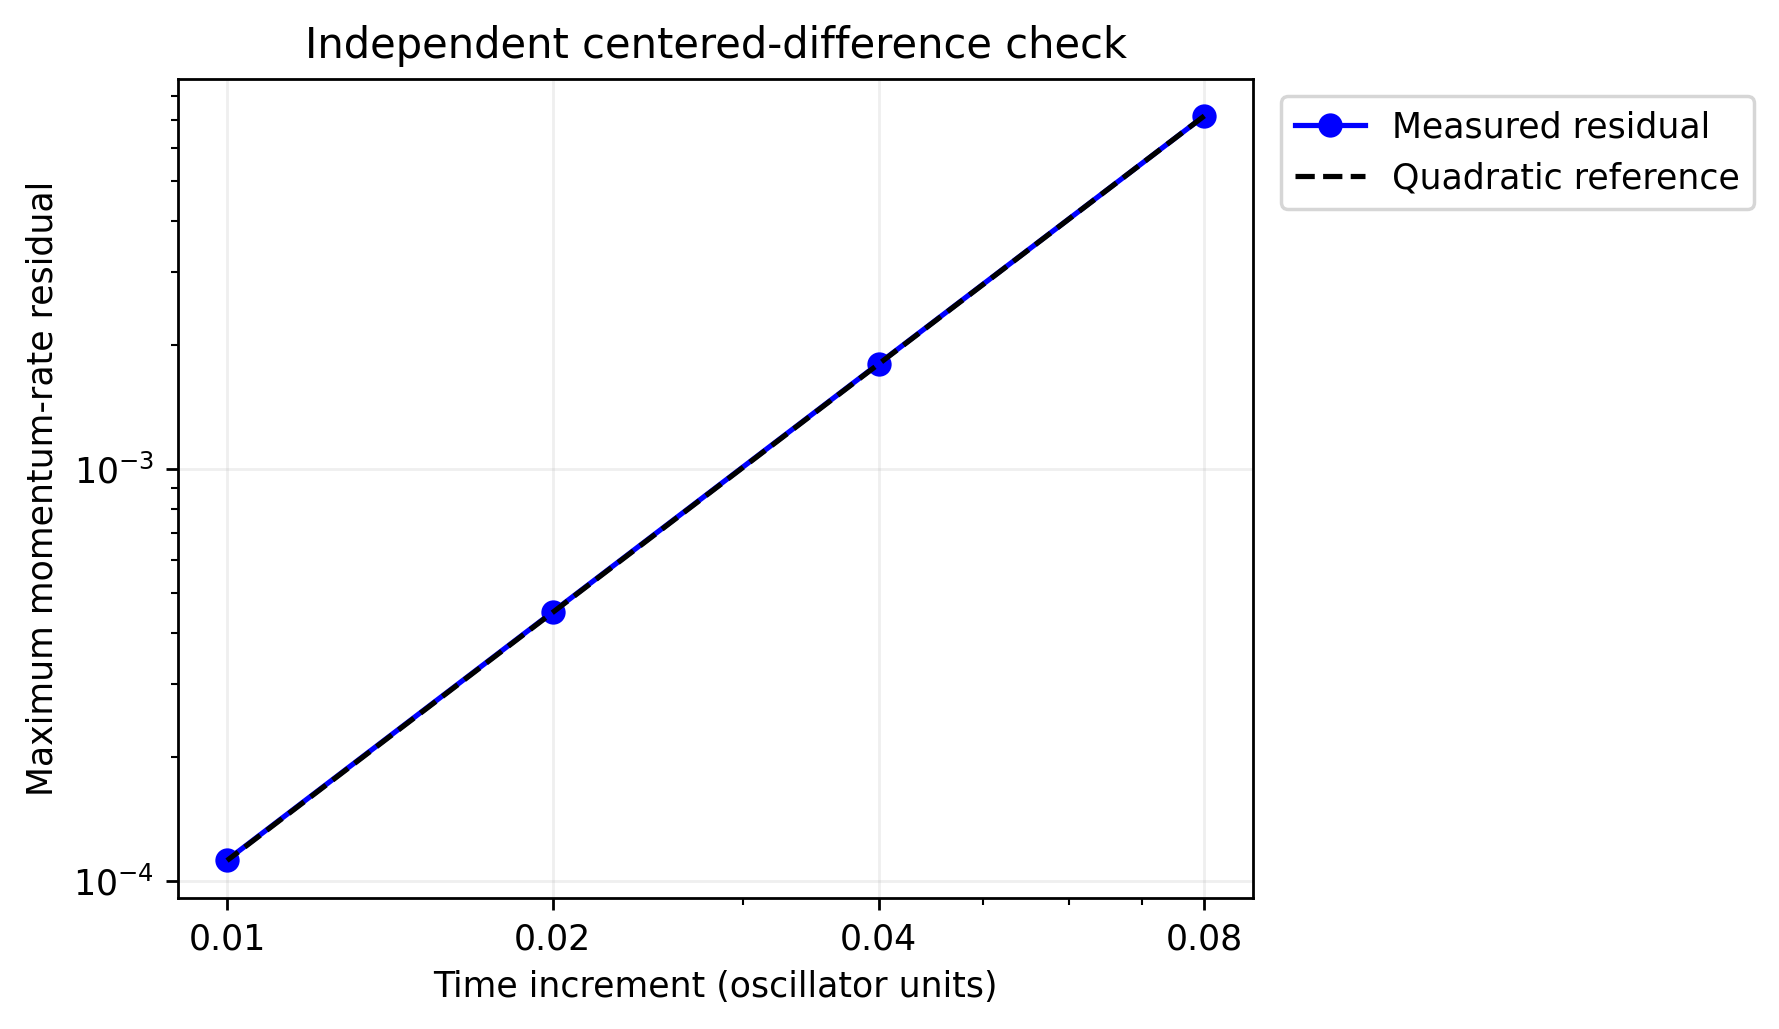

Conditional symbolic checks and finite-model integrity checks passed.
Inspect basis and derivative convergence for the selected controls.


In [22]:
"""Check independent time derivatives and report convergence quantitatively."""

probe_times = np.linspace(0.5, EH_TIME_STOP - 0.5, 41)
assert EH_TIME_STOP > 1.0
reference = eh_simulate(EH_CHECK_BASIS_SIZE, EH_QUARTIC_STRENGTH, probe_times)
eh_convergence_rows = []
for step in EH_DERIVATIVE_STEPS:
    assert step > 0
    plus = eh_simulate(
        EH_CHECK_BASIS_SIZE, EH_QUARTIC_STRENGTH, probe_times + step
    )
    minus = eh_simulate(
        EH_CHECK_BASIS_SIZE, EH_QUARTIC_STRENGTH, probe_times - step
    )
    derivative = (plus["p"] - minus["p"]) / (2 * step)
    error = np.max(np.abs(derivative - reference["dp_commutator"]))
    eh_convergence_rows.append(
        {"time_increment": step, "maximum_residual": error}
    )
eh_convergence_table = pd.DataFrame(eh_convergence_rows)
display(eh_convergence_table)
figure, axis = plt.subplots(figsize=(7, 4), dpi=EH_DPI, layout="constrained")
steps = eh_convergence_table["time_increment"].to_numpy()
errors = eh_convergence_table["maximum_residual"].to_numpy()
axis.loglog(steps, errors, "o-", color="#0000ff", label="Measured residual")
axis.loglog(
    steps,
    errors[0] * (steps / steps[0]) ** 2,
    "--",
    color="black",
    label="Quadratic reference",
)
axis.set(
    xlabel="Time increment (oscillator units)",
    ylabel="Maximum momentum-rate residual",
    title="Independent centered-difference check",
)
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

axis.xaxis.set_major_locator(FixedLocator(steps))
axis.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:g}")
)
axis.xaxis.set_minor_formatter(NullFormatter())
axis.grid(alpha=0.2)
convergence_buffer = BytesIO()
figure.savefig(convergence_buffer, format="png", bbox_inches="tight")
eh_convergence_png = convergence_buffer.getvalue()
plt.show()
plt.close(figure)

assert nx.is_directed_acyclic_graph(eh_graph)
assert eh_adjacency.nnz == eh_graph.number_of_edges()
for source, target in eh_graph.edges:
    assert eh_verify(
        eh_graph.nodes[source]["expr"], eh_graph.nodes[target]["expr"]
    )["proved"]
for run in eh_runs.values():
    assert run["norm_error"] < 1e-10
    assert (
        np.max(
            np.abs(
                run["force"] - run["force_at_mean"] - run["moment_correction"]
            )
        )
        < 1e-9
    )
harmonic_exact = EH_INITIAL_POSITION * np.cos(
    eh_times
) + EH_INITIAL_MOMENTUM * np.sin(eh_times)
assert np.max(np.abs(eh_runs["Harmonic"]["x"] - harmonic_exact)) < 1e-9
print("Conditional symbolic checks and finite-model integrity checks passed.")
print("Inspect basis and derivative convergence for the selected controls.")


## Export and physical conclusion

Harmonic motion restricts the wavepacket center to perfectly trace the classical trajectory independent of the finite spatial width. Introducing a quartic potential couples the mean acceleration to higher-order spatial moments, producing a physical force discrepancy captured exactly by the derived polynomial identity. Evaluating the generated derivation graph exposes the conditional algebraic transformations, supplementing the numerical diagnostics that quantify truncation artifacts and finite-difference differentiation errors.

The final export archive bundles the directed derivation graph into DOT and PNG image formats alongside the exact LaTeX expressions and machine-readable logical assumptions. Retaining the generated diagnostic tables and associated plots preserves the numerical integration checks evaluated under the specified configuration controls. Activating the `EH_DOWNLOAD_ZIP` execution flag triggers the automated transfer of this comprehensive computational archive to the local filesystem upon completion of the simulation pipeline.

## References

[1] P. Ehrenfest (1927), “Bemerkung über die angenäherte Gültigkeit der klassischen Mechanik innerhalb der Quantenmechanik,” *Zeitschrift für Physik*, **45**, 455–457. [DOI](https://doi.org/10.1007/BF01329203).

[2] SymPy Development Team, “Commutator,” *SymPy documentation*. [Operator API](https://docs.sympy.org/latest/modules/physics/quantum/commutator.html).

[3] NumPy Developers, “numpy.linalg.eigh,” *NumPy documentation*. [Hermitian eigendecomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html).

In [23]:
"""Export the graph, mathematical assumptions, numerical tables, and figures."""

(EH_OUTPUT_DIRECTORY / "ehrenfest_graph.dot").write_text(eh_dot.source)
(EH_OUTPUT_DIRECTORY / "ehrenfest_graph.png").write_bytes(eh_graph_png)
(EH_OUTPUT_DIRECTORY / "ehrenfest_motion.png").write_bytes(eh_motion_png)
(EH_OUTPUT_DIRECTORY / "ehrenfest_convergence.png").write_bytes(
    eh_convergence_png
)
eh_diagnostic_table.to_csv(
    EH_OUTPUT_DIRECTORY / "basis_checks.csv", index=False
)
eh_convergence_table.to_csv(
    EH_OUTPUT_DIRECTORY / "time_checks.csv", index=False
)
export_record = {
    "assumptions": EH_ASSUMPTIONS,
    "proof_scope": "exact ordered algebra conditional on declared assumptions",
    "nodes": [
        {"id": index, "expression": sp.sstr(eh_graph.nodes[key]["expr"])}
        for index, key in enumerate(eh_node_order)
    ],
    "edges": [
        {
            "from": eh_node_order.index(source),
            "to": eh_node_order.index(target),
            "rule": data["rule"],
            "verification": data["verification"],
        }
        for source, target, data in eh_graph.edges(data=True)
    ],
    "backend": "CuPy" if EH_XP is cp else "NumPy",
    "controls": {
        "basis": EH_BASIS_SIZE,
        "check_basis": EH_CHECK_BASIS_SIZE,
        "quartic": EH_QUARTIC_STRENGTH,
        "time_stop": EH_TIME_STOP,
        "time_points": EH_TIME_POINTS,
        "x0": EH_INITIAL_POSITION,
        "p0": EH_INITIAL_MOMENTUM,
    },
}
(EH_OUTPUT_DIRECTORY / "derivation_record.json").write_text(
    json.dumps(export_record, indent=2)
)
latex_export = [
    r"\documentclass{article}",
    r"\usepackage{amsmath,amssymb}",
    r"\begin{document}",
    r"\section*{Ehrenfest derivation}",
    "Exact ordered algebra under declared analytic assumptions.",
]
for index, step in enumerate(eh_result["selected_path"]):
    latex_export.extend(
        [r"\[", rf"E_{{{index}}}:={sp.latex(step['expr'])}", r"\]"]
    )
    latex_export.append(
        (step["rule"] or "Initial expression").replace("_", " ") + "."
    )
latex_export.append(r"\end{document}")
(EH_OUTPUT_DIRECTORY / "ehrenfest_derivation.tex").write_text(
    "\n".join(latex_export)
)
eh_zip_path = Path("ehrenfest_example_outputs.zip")
with zipfile.ZipFile(
    eh_zip_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(EH_OUTPUT_DIRECTORY.iterdir()):
        if path.is_file():
            archive.write(path, arcname=path.name)
display(FileLink(str(eh_zip_path)))
if EH_DOWNLOAD_ZIP:
    from google.colab import files

    files.download(str(eh_zip_path))

/content/ehrenfest_example_outputs.zip